# Project 4: TIC-TAC-TOE with Reinforcement Learning

This project implements and evaluates four reinforcement-learning approaches for Tic-Tac-Toe: Monte Carlo, Q-learning, DQN, and DDQN. Each method is trained, evaluated against a random opponent, and analyzed through controlled experiments.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

my_path = "/content/drive/MyDrive/Projects/Project 4/"

Mounted at /content/drive


## Experiment Setup

The following cell defines the project paths, random seed, and utility functions used to save and load trained artifacts. Existing artifacts are loaded by default; set `FORCE_TRAIN = True` only when retraining is required.

In [3]:
import pickle
import random
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm


PROJECT_PATH = Path(my_path)
SAVED_MODELS_PATH = PROJECT_PATH / "saved_models"
RESULTS_PATH = PROJECT_PATH / "results"

MC_MODELS_PATH = SAVED_MODELS_PATH / "monte_carlo"
MC_RESULTS_PATH = RESULTS_PATH / "monte_carlo"

Q_MODELS_PATH = SAVED_MODELS_PATH / "q_learning"
Q_BASELINE_MODELS_PATH = Q_MODELS_PATH / "baseline"
Q_EXPERIMENT_MODELS_PATH = Q_MODELS_PATH / "experiments"
Q_RESULTS_PATH = RESULTS_PATH / "q_learning"
Q_BASELINE_RESULTS_PATH = Q_RESULTS_PATH / "baseline"
Q_HISTORY_PATH = Q_RESULTS_PATH / "histories"
Q_EVALUATION_PATH = Q_RESULTS_PATH / "evaluations"

DQN_MODELS_PATH = SAVED_MODELS_PATH / "dqn"
DDQN_MODELS_PATH = SAVED_MODELS_PATH / "ddqn"

dirs_to_create = [
    MC_MODELS_PATH,
    MC_RESULTS_PATH,
    Q_BASELINE_MODELS_PATH,
    Q_EXPERIMENT_MODELS_PATH,
    Q_BASELINE_RESULTS_PATH,
    Q_HISTORY_PATH,
    Q_EVALUATION_PATH,
    DQN_MODELS_PATH,
    DDQN_MODELS_PATH
]

for path in dirs_to_create:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
FORCE_TRAIN = False
BOARD_SIZE = 3
ACTION_SIZE = BOARD_SIZE**2


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Random seed set to: {seed}")


def save_pickle(data, filepath):
    path = Path(filepath)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as file:
        pickle.dump(data, file)
    print(f"Artifact saved: {path}")


def load_pickle(filepath):
    path = Path(filepath)
    with open(path, "rb") as file:
        data = pickle.load(file)
    print(f"Artifact loaded: {path}")
    return data


def should_train(filepath):
    path = Path(filepath)
    return FORCE_TRAIN or not path.exists()


set_seed()
print(f"PROJECT_PATH: {PROJECT_PATH}")

Random seed set to: 42
PROJECT_PATH: /content/drive/MyDrive/Projects/Project 4


# Tic Tac Toe Environment
This TicTacToe class defines the structure and logic for a customizable Tic Tac Toe game. The class initializes with an optional size parameter (defaulting to 3x3), sets up an empty game board, and tracks the current winner, which is initially set to None. Key methods include print_board to display the current state of the board, available_moves to list possible moves, make_move to update the board with a player's move, and winner to check if a move results in a win. The class also includes utility functions like empty_squares and num_empty_squares to assess the board's status.

***no modifications are required from participants. The class is ready to be used directly in the exercise.***

### Implementation Note

The supplied `TicTacToe` class manages the board, legal moves, move execution, and winner detection. The anti-diagonal condition was corrected so that a win is detected regardless of which diagonal square was played last.

In [4]:
class TicTacToe:
    def __init__(self, size=3):
        self.size = size
        self.board = [" " for _ in range(size * size)]
        self.current_winner = None

    def print_board(self):
        rows = [
            self.board[i * self.size:(i + 1) * self.size]
            for i in range(self.size)
        ]
        for row in rows:
            print("| " + " | ".join(row) + " |")

    @staticmethod
    def print_board_nums(size):
        number_board = [
            [str(i) for i in range(j * size, (j + 1) * size)]
            for j in range(size)
        ]
        for row in number_board:
            print("| " + " | ".join(row) + " |")

    def available_moves(self):
        return [i for i, spot in enumerate(self.board) if spot == " "]

    def total_moves(self):
        return [i for i, _ in enumerate(self.board)]

    def empty_squares(self):
        return " " in self.board

    def num_empty_squares(self):
        return self.board.count(" ")

    def make_move(self, square, letter):
        if self.board[square] == " ":
            self.board[square] = letter
            if self.winner(square, letter):
                self.current_winner = letter
            return self.board

        print("INVALID SQUARE:", square)

    def winner(self, square, letter):
        row_index = square // self.size
        row = self.board[row_index * self.size:(row_index + 1) * self.size]
        if all(spot == letter for spot in row):
            return True

        column_index = square % self.size
        column = [
            self.board[column_index + i * self.size]
            for i in range(self.size)
        ]
        if all(spot == letter for spot in column):
            return True

        if square % (self.size + 1) == 0:
            main_diagonal = [
                self.board[i]
                for i in range(0, self.size * self.size, self.size + 1)
            ]
            if all(spot == letter for spot in main_diagonal):
                return True

        is_anti_diagonal_square = (
            square % (self.size - 1) == 0
            and square not in (0, self.size**2 - 1)
        )
        if is_anti_diagonal_square:
            anti_diagonal = [
                self.board[i]
                for i in range(
                    self.size - 1,
                    self.size * self.size - 1,
                    self.size - 1
                )
            ]
            if all(spot == letter for spot in anti_diagonal):
                return True

        return False

# 1. Monte Carlo

The following TicTacToe MonteCarlo class implements the Monte Carlo learning method to optimize the game strategy for Tic Tac Toe. It is initialized with parameters for the game size, learning rate, discount factor, and exploration rate (epsilon). The class manages a Q-table for storing the value estimates for each state-action pair, and employs an epsilon-greedy strategy for action selection to balance between exploration and exploitation.

Key functionalities include:

* state_to_str(state): Converts the game state to a string key for Q-table referencing.
* select_action(state, moves): Determines the next action using an epsilon-greedy approach. It randomly selects an action with a probability of epsilon for exploration; otherwise, it chooses the action with the highest estimated value from the Q-table for exploitation.
* update_q_table(episode, reward): Updates the Q-table based on the total reward obtained at the end of an episode. This method employs the Monte Carlo approach by updating the Q-values for all unique state-action pairs visited in an episode, applying a learning rate to adjust values towards the observed total reward.
* train(episodes): Conducts multiple episodes of game simulations to train the model. During each episode, the game is played until there are no more moves or a player wins. Rewards are assigned based on the game outcome, and the Q-table is updated with the cumulative reward of the episode.

***no modifications are required from participants. The class is ready to be used directly in the exercise.***

In [ ]:
class TicTacToeMonteCarlo:
    def __init__(self, size=3, learning_rate=0.1, discount_factor=0.9, epsilon=0.1):
        self.size = size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.q_table = {}
        self.game = TicTacToe(size)
        self.player_1 = 'X'
        self.player_2 = 'O'

    def state_to_str(self, state):
        return ''.join(state)

    def select_action(self, state, moves):
        state_str = self.state_to_str(state)
        if np.random.rand() < self.epsilon:
            return random.choice(moves)
        else:
            if state_str not in self.q_table:
                return random.choice(moves)
            filtered_items = [(key, value) for key, value in self.q_table[state_str].items() if key in moves]
            return max(filtered_items, key=lambda item: item[1])[0]

    def update_q_table(self, episode, reward):
        visited_states = set()
        for state, action in episode:
            state_str = self.state_to_str(state)
            if state_str not in visited_states:
                if state_str not in self.q_table:
                    self.q_table[state_str] = {}
                if action not in self.q_table[state_str]:
                    self.q_table[state_str][action] = 0
                self.q_table[state_str][action] += self.learning_rate * (reward - self.q_table[state_str][action])
                visited_states.add(state_str)

    def train(self, episodes):
        for _ in tqdm(range(episodes)):
          game_over = False
          episode = []
          self.game = TicTacToe(self.size)
          current_state = self.game.board.copy()
          total_reward = 0
          letter = self.player_1
          while self.game.empty_squares():
            moves = self.game.available_moves()
            if letter == self.player_2:
              square = random.choice(moves)
            else:
              square = self.select_action(current_state, moves)
            episode.append((current_state, square))
            next_state = self.game.make_move(square, letter)

            if self.game.current_winner:
              if letter == self.player_1:
                reward = 1 # win
              else:
                reward = -1.5 # loose
              game_over = True
              break
            else:
              reward = 0.0001

            total_reward += reward
            current_state = next_state.copy()
            letter = self.player_2 if letter == self.player_1 else self.player_1  # Switch player
          if not game_over:
            reward = 0.5
          total_reward += reward
          self.update_q_table(episode, total_reward)

## 1.a - Monte Carlo Baseline

The Monte Carlo agent is trained with the required baseline parameters for 100,000 episodes. If a saved artifact exists, it is loaded instead. The trained policy is then evaluated greedily against a seeded random opponent over 1,000 games.

In [ ]:
size = BOARD_SIZE
learning_rate = 0.001
discount_factor = 0.99
epsilon = 0.1
episodes = 100000

MC_BASE_FILE = MC_MODELS_PATH / "mc_base.pkl"

set_seed(SEED)

if should_train(MC_BASE_FILE):
    mc = TicTacToeMonteCarlo(
        size=size,
        learning_rate=learning_rate,
        discount_factor=discount_factor,
        epsilon=epsilon
    )
    mc.train(episodes)
    save_pickle(mc, MC_BASE_FILE)
else:
    mc = load_pickle(MC_BASE_FILE)

print("--- Baseline Parameters ---")
print(f"Size: {size}, LR: {learning_rate}, Gamma: {discount_factor}, Epsilon: {epsilon}, Episodes: {episodes:,}")
print(f"States in Q-table: {len(mc.q_table)}")

Random seed set to: 42


100%|██████████| 100000/100000 [00:03<00:00, 29157.38it/s]

Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/monte_carlo/mc_base.pkl
--- Baseline Parameters ---
Size: 3, LR: 0.001, Gamma: 0.99, Epsilon: 0.1, Episodes: 100,000
States in Q-table: 3981


### Baseline Evaluation

The saved baseline policy is evaluated greedily over 1,000 games against a seeded random opponent. Exploration is disabled so that the results reflect the learned policy.

In [ ]:
def evaluate_mc_agent(mc_agent, num_games=1000, seed=2026):
    rng = random.Random(seed)
    wins, losses, ties = 0, 0, 0

    for _ in range(num_games):
        game = TicTacToe(mc_agent.size)
        current_state = game.board.copy()
        letter = mc_agent.player_1

        while game.empty_squares():
            moves = game.available_moves()

            if letter == mc_agent.player_2:
                square = rng.choice(moves)
            else:
                state_str = mc_agent.state_to_str(current_state)
                if state_str in mc_agent.q_table:
                    q_values = mc_agent.q_table[state_str]
                    legal_q = {action: q_values[action] for action in moves if action in q_values}
                    square = max(legal_q, key=legal_q.get) if legal_q else rng.choice(moves)
                else:
                    square = rng.choice(moves)

            game.make_move(square, letter)

            if game.current_winner:
                if letter == mc_agent.player_1:
                    wins += 1
                else:
                    losses += 1
                break

            current_state = game.board.copy()
            letter = mc_agent.player_2 if letter == mc_agent.player_1 else mc_agent.player_1
        else:
            ties += 1

    assert wins + losses + ties == num_games

    return {
        "evaluation_games": num_games,
        "wins": wins,
        "losses": losses,
        "ties": ties,
        "win_rate": wins / num_games * 100,
        "loss_rate": losses / num_games * 100,
        "tie_rate": ties / num_games * 100
    }


mc_base_results = evaluate_mc_agent(mc, num_games=1000, seed=2026)

print("--- Monte Carlo Baseline Evaluation ---")
print(f"Games: {mc_base_results['evaluation_games']}")
print(f"Wins: {mc_base_results['wins']} ({mc_base_results['win_rate']:.2f}%)")
print(f"Losses: {mc_base_results['losses']} ({mc_base_results['loss_rate']:.2f}%)")
print(f"Ties: {mc_base_results['ties']} ({mc_base_results['tie_rate']:.2f}%)")

--- Monte Carlo Baseline Evaluation ---
Games: 1000
Wins: 863 (86.30%)
Losses: 20 (2.00%)
Ties: 117 (11.70%)


### Game Play

The following seeded game demonstrates how the trained Monte Carlo policy selects greedy legal actions against a random opponent.

In [ ]:
def play_mc_demo(mc_agent, seed=7, title="Monte Carlo Demo Game"):
    rng = random.Random(seed)
    game = TicTacToe(mc_agent.size)
    current_state = game.board.copy()
    letter = mc_agent.player_1

    print(f"=== {title} ===")

    while game.empty_squares():
        moves = game.available_moves()

        if letter == mc_agent.player_2:
            square = rng.choice(moves)
            print(f"Opponent O chooses: {square}")
        else:
            state_str = mc_agent.state_to_str(current_state)
            q_values = mc_agent.q_table.get(state_str, {})
            legal_q = {action: q_values[action] for action in moves if action in q_values}
            square = max(legal_q, key=legal_q.get) if legal_q else rng.choice(moves)
            print(f"Agent X chooses: {square}")

        game.make_move(square, letter)
        game.print_board()
        print("-" * 32)

        if game.current_winner:
            result = "win" if letter == mc_agent.player_1 else "loss"
            winner = "Agent X" if result == "win" else "Random opponent O"
            print(f"Result: {winner} wins!")
            return result

        current_state = game.board.copy()
        letter = mc_agent.player_2 if letter == mc_agent.player_1 else mc_agent.player_1

    print("Result: Tie")
    return "tie"


mc_base_demo_result = play_mc_demo(mc, seed=7, title="Monte Carlo Baseline - Demo Game")

=== Monte Carlo Baseline - Demo Game ===
Agent X chooses: 1
|   | X |   |
|   |   |   |
|   |   |   |
--------------------------------
Opponent O chooses: 6
|   | X |   |
|   |   |   |
| O |   |   |
--------------------------------
Agent X chooses: 2
|   | X | X |
|   |   |   |
| O |   |   |
--------------------------------
Opponent O chooses: 3
|   | X | X |
| O |   |   |
| O |   |   |
--------------------------------
Agent X chooses: 0
| X | X | X |
| O |   |   |
| O |   |   |
--------------------------------
Result: Agent X wins!


## 1.b - Monte Carlo Hyperparameter Experiments

Each experiment changes one hyperparameter while keeping the remaining baseline settings fixed. This one-factor-at-a-time design isolates the effect of learning rate, discount factor, epsilon, and training episodes.

In [ ]:
def run_mc_experiment(
    experiment_name,
    filepath,
    learning_rate=0.001,
    discount_factor=0.99,
    epsilon=0.1,
    episodes=100000
):
    set_seed(SEED)

    if should_train(filepath):
        agent = TicTacToeMonteCarlo(
            size=BOARD_SIZE,
            learning_rate=learning_rate,
            discount_factor=discount_factor,
            epsilon=epsilon
        )
        agent.train(episodes)
        save_pickle(agent, filepath)
    else:
        agent = load_pickle(filepath)

    results = evaluate_mc_agent(agent, num_games=1000, seed=2026)

    result_dict = {
        "experiment": experiment_name,
        "learning_rate": learning_rate,
        "discount_factor": discount_factor,
        "epsilon": epsilon,
        "episodes": episodes,
        "states": len(agent.q_table),
        "evaluation_games": results["evaluation_games"],
        "wins": results["wins"],
        "losses": results["losses"],
        "ties": results["ties"],
        "win_rate": results["win_rate"],
        "loss_rate": results["loss_rate"],
        "tie_rate": results["tie_rate"]
    }

    print(
        f"{experiment_name} | Win: {results['win_rate']:.2f}% | "
        f"Loss: {results['loss_rate']:.2f}% | Tie: {results['tie_rate']:.2f}%"
    )
    return agent, result_dict


mc_agents = {"base": mc}
mc_results = [{
    "experiment": "base",
    "learning_rate": learning_rate,
    "discount_factor": discount_factor,
    "epsilon": epsilon,
    "episodes": episodes,
    "states": len(mc.q_table),
    "evaluation_games": mc_base_results["evaluation_games"],
    "wins": mc_base_results["wins"],
    "losses": mc_base_results["losses"],
    "ties": mc_base_results["ties"],
    "win_rate": mc_base_results["win_rate"],
    "loss_rate": mc_base_results["loss_rate"],
    "tie_rate": mc_base_results["tie_rate"]
}]

In [ ]:
# Learning rate
for lr in [0.0001, 0.01, 0.1]:
    name = f"lr_{lr}"
    filepath = MC_MODELS_PATH / f"mc_lr_{lr}.pkl"
    agent, result = run_mc_experiment(name, filepath, learning_rate=lr)
    mc_agents[name] = agent
    mc_results.append(result)

# Discount factor
for df in [0.1, 0.9, 0.999]:
    name = f"gamma_{df}"
    filepath = MC_MODELS_PATH / f"mc_gamma_{df}.pkl"
    agent, result = run_mc_experiment(name, filepath, discount_factor=df)
    mc_agents[name] = agent
    mc_results.append(result)

# Epsilon
for eps in [0.01, 0.3, 0.5]:
    name = f"eps_{eps}"
    filepath = MC_MODELS_PATH / f"mc_eps_{eps}.pkl"
    agent, result = run_mc_experiment(name, filepath, epsilon=eps)
    mc_agents[name] = agent
    mc_results.append(result)

# Training episodes
for ep in [10000, 50000, 200000]:
    name = f"episodes_{ep}"
    filepath = MC_MODELS_PATH / f"mc_ep_{ep}.pkl"
    agent, result = run_mc_experiment(name, filepath, episodes=ep)
    mc_agents[name] = agent
    mc_results.append(result)

# Prevent duplicates when this cell is executed more than once
mc_results = list({result["experiment"]: result for result in mc_results}.values())

mc_results_df = pd.DataFrame(mc_results)
rate_cols = ["win_rate", "loss_rate", "tie_rate"]
mc_results_df[rate_cols] = mc_results_df[rate_cols].round(2)

MC_RESULTS_FILE = MC_RESULTS_PATH / "mc_results.csv"
mc_results_df.to_csv(MC_RESULTS_FILE, index=False)
print(f"Monte Carlo results saved to: {MC_RESULTS_FILE}")


def display_mc_comparison(title, pattern, parameter):
    columns = ["experiment", parameter, "states"] + rate_cols
    comparison = mc_results_df[mc_results_df["experiment"].str.contains(f"{pattern}|base")]
    print(f"\n--- {title} ---")
    display(comparison[columns].sort_values(parameter))


display_mc_comparison("Learning Rate Comparison", "lr", "learning_rate")
display_mc_comparison("Discount Factor Comparison", "gamma", "discount_factor")
display_mc_comparison("Epsilon Comparison", "eps", "epsilon")
display_mc_comparison("Episodes Comparison", "episodes", "episodes")

Random seed set to: 42


100%|██████████| 100000/100000 [00:04<00:00, 22048.13it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/monte_carlo/mc_lr_0.0001.pkl
lr_0.0001 | Win: 83.90% | Loss: 2.00% | Tie: 14.10%
Random seed set to: 42


100%|██████████| 100000/100000 [00:03<00:00, 28878.86it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/monte_carlo/mc_lr_0.01.pkl
lr_0.01 | Win: 83.70% | Loss: 1.80% | Tie: 14.50%
Random seed set to: 42


...

,experiment,discount_factor,states,win_rate,loss_rate,tie_rate
4,gamma_0.1,0.100,3981,86.3,2.0,11.7
5,gamma_0.9,0.900,3981,86.3,2.0,11.7
0,base,0.990,3981,86.3,2.0,11.7
6,gamma_0.999,0.999,3981,86.3,2.0,11.7



--- Epsilon Comparison ---


,experiment,epsilon,states,win_rate,loss_rate,tie_rate
7,eps_0.01,0.01,2425,85.2,6.3,8.5
0,base,0.10,3981,86.3,2.0,11.7
8,eps_0.3,0.30,4514,90.0,0.7,9.3
9,eps_0.5,0.50,4520,92.3,0.1,7.6



--- Episodes Comparison ---


,experiment,episodes,states,win_rate,loss_rate,tie_rate
10,episodes_10000,10000,2530,84.5,3.9,11.6
11,episodes_50000,50000,3628,86.3,2.0,11.7
0,base,100000,3981,86.3,2.0,11.7
12,episodes_200000,200000,4248,86.4,1.9,11.7


### 1.b - Results and Discussion

All configurations were trained with seed `42` and evaluated greedily over the same 1,000 games using seed `2026`. Each experiment changed one parameter relative to the baseline.

#### Learning Rate

`learning_rate=0.1` produced the strongest policy: the win rate increased from 86.3% to 94.5%, losses fell from 2.0% to 0.0%, and ties fell from 11.7% to 5.5%. However, the relationship was not monotonic, since `0.01` performed slightly worse than the baseline. A larger learning rate can adapt faster, but may also produce greater training variation.

#### Discount Factor

All tested discount factors produced identical results. In the supplied implementation, `discount_factor` is stored but is not used in the return or Q-value update. Therefore, changing it cannot affect training. A separate DF-active investigation later demonstrates its theoretical effect without modifying the supplied class.

#### Epsilon

Reducing epsilon to `0.01` limited exploration, reduced the number of visited states, and increased the loss rate. Increasing epsilon to `0.5` expanded state coverage and improved the greedy policy to 92.3% wins and 0.1% losses. In this experiment, broader exploration helped the agent learn more reliable actions against the random opponent.

#### Training Episodes

Increasing training from 10,000 to 50,000 episodes improved performance and state coverage. Results then plateaued: 100,000 and 200,000 episodes produced nearly identical evaluation rates, although the Q-table continued to grow. Additional experience therefore expanded coverage without materially changing the evaluated policy.

#### Overall Interpretation

Learning rate had the largest effect on final performance, epsilon controlled exploration and state coverage, and additional episodes produced diminishing returns. The discount factor had no effect because it was inactive in the supplied implementation. These conclusions describe one controlled seeded run and should not be treated as universal optimal values.

## 1.c - Performance Comparison and Visualization

The two strongest individual adjustments were selected for comparison with the baseline:

- `learning_rate=0.1`: 94.5% wins and 0.0% losses.
- `epsilon=0.5`: 92.3% wins and 0.1% losses.

Each comparison changes only one baseline parameter.

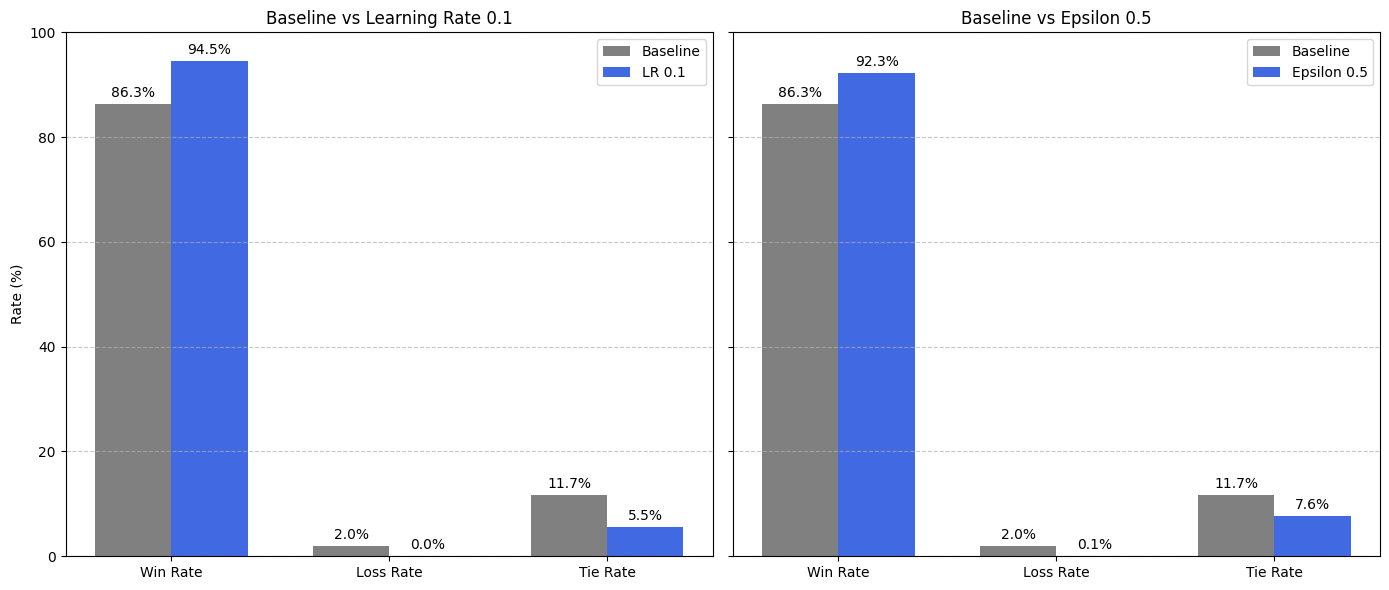

In [ ]:
selected_results = mc_results_df.set_index("experiment")
base_result = selected_results.loc["base"]
lr_result = selected_results.loc["lr_0.1"]
epsilon_result = selected_results.loc["eps_0.5"]

metrics = ["win_rate", "loss_rate", "tie_rate"]
metric_labels = ["Win Rate", "Loss Rate", "Tie Rate"]
x = np.arange(len(metrics))
width = 0.35


def plot_mc_comparison(ax, adjusted_result, adjusted_label, title):
    baseline_bars = ax.bar(
        x - width / 2, base_result[metrics], width, label="Baseline", color="gray"
    )
    adjusted_bars = ax.bar(
        x + width / 2, adjusted_result[metrics], width,
        label=adjusted_label, color="royalblue"
    )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.bar_label(baseline_bars, fmt="%.1f%%", padding=3)
    ax.bar_label(adjusted_bars, fmt="%.1f%%", padding=3)


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

plot_mc_comparison(axes[0], lr_result, "LR 0.1", "Baseline vs Learning Rate 0.1")
plot_mc_comparison(axes[1], epsilon_result, "Epsilon 0.5", "Baseline vs Epsilon 0.5")
axes[0].set_ylabel("Rate (%)")

plt.tight_layout()
plt.show()

### 1.c - Comparison Discussion

Increasing the learning rate from `0.001` to `0.1` raised the win rate from 86.3% to 94.5%, eliminated observed losses, and reduced ties from 11.7% to 5.5%. The larger learning rate achieved stronger final performance, although the later convergence analysis shows greater training variation.

Increasing epsilon from `0.1` to `0.5` raised the win rate to 92.3% and reduced losses to 0.1%. It also increased the number of represented states from 3,981 to 4,520, indicating broader exploration during training.

Both adjustments improved the final greedy policy under the fixed seeds. Learning rate `0.1` achieved the strongest final result, while epsilon `0.5` demonstrated the benefit of greater state-space exploration.

### Optional Extension — Combined Hyperparameters

The required comparisons above isolate the individual effects of `learning_rate=0.1` and `epsilon=0.5`.

This optional experiment combines these two strongest individual configurations to examine whether their benefits are additive. Because both parameters are changed simultaneously, the experiment measures their joint outcome and does not isolate the individual causal contribution of either parameter.

In [ ]:
MC_COMBINED_FILE = MC_MODELS_PATH / "mc_lr_0.1_eps_0.5.pkl"
combined_name = "lr_0.1_eps_0.5"

mc_combined, mc_combined_result = run_mc_experiment(
    experiment_name=combined_name,
    filepath=MC_COMBINED_FILE,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon=0.5,
    episodes=100000
)

mc_agents[combined_name] = mc_combined

selected_experiments = ["base", "lr_0.1", "eps_0.5", combined_name]
mc_1c_summary_df = pd.DataFrame(mc_results + [mc_combined_result])
mc_1c_summary_df = mc_1c_summary_df[
    mc_1c_summary_df["experiment"].isin(selected_experiments)
].copy()

mc_1c_summary_df["experiment"] = pd.Categorical(
    mc_1c_summary_df["experiment"],
    categories=selected_experiments,
    ordered=True
)
mc_1c_summary_df = mc_1c_summary_df.sort_values("experiment")

display_columns = [
    "experiment",
    "learning_rate",
    "epsilon",
    "states",
    "win_rate",
    "loss_rate",
    "tie_rate"
]
display_df = mc_1c_summary_df[display_columns].copy()
display_df[rate_cols] = display_df[rate_cols].round(1)
display(display_df)

if combined_name not in mc_results_df["experiment"].values:
    mc_results_df = pd.concat(
        [mc_results_df, pd.DataFrame([mc_combined_result])],
        ignore_index=True
    )

mc_results_df.to_csv(MC_RESULTS_FILE, index=False)
print(f"Updated results saved to: {MC_RESULTS_FILE}")

Random seed set to: 42


100%|██████████| 100000/100000 [00:03<00:00, 27777.18it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/monte_carlo/mc_lr_0.1_eps_0.5.pkl
lr_0.1_eps_0.5 | Win: 88.50% | Loss: 0.70% | Tie: 10.80%


,experiment,learning_rate,epsilon,states,win_rate,loss_rate,tie_rate
0,base,0.001,0.1,3981,86.3,2.0,11.7
3,lr_0.1,0.100,0.1,4276,94.5,0.0,5.5
9,eps_0.5,0.001,0.5,4520,92.3,0.1,7.6
13,lr_0.1_eps_0.5,0.100,0.5,4520,88.5,0.7,10.8


Updated results saved to: /content/drive/MyDrive/Projects/Project 4/results/monte_carlo/mc_results.csv


### Combined Hyperparameter Experiment - Results

Combining `learning_rate=0.1` and `epsilon=0.5` improved upon the baseline, reaching 88.5% wins, 0.7% losses and 10.8% ties. However, it performed worse than either adjustment individually.

The improvements were therefore not additive in this run. One possible explanation is that greater exploration produced more varied trajectories while the larger learning rate increased the influence of individual returns. The experiment demonstrates an interaction between the settings, but does not establish why it occurred or whether it generalizes across seeds.

# Additional Investigation - Active Discount Factor

In the supplied Monte Carlo class, `discount_factor` is stored but is not used in the Q-value update. Consequently, changing gamma produced identical results under matched seeds.

To examine its intended effect without modifying the supplied solution, the following optional implementation uses:

$$G_t = \gamma^{T-1-t}R$$

Earlier actions receive more heavily discounted episode outcomes when gamma is small. The original and DF-active implementations are evaluated under the same experimental conditions.

In [ ]:
MC_DF_MODELS_PATH = MC_MODELS_PATH / "discount_factor_investigation"
MC_DF_RESULTS_PATH = MC_RESULTS_PATH / "discount_factor_investigation"

for path in [MC_DF_MODELS_PATH, MC_DF_RESULTS_PATH]:
    path.mkdir(parents=True, exist_ok=True)


class TicTacToeMonteCarloDF(TicTacToeMonteCarlo):
    def update_q_table(self, episode, reward):
        visited_states = set()
        episode_length = len(episode)

        for step_index, (state, action) in enumerate(episode):
            state_str = self.state_to_str(state)

            if state_str in visited_states:
                continue

            if state_str not in self.q_table:
                self.q_table[state_str] = {}
            if action not in self.q_table[state_str]:
                self.q_table[state_str][action] = 0

            steps_to_end = episode_length - 1 - step_index
            discounted_reward = self.discount_factor**steps_to_end * reward
            current_q = self.q_table[state_str][action]
            self.q_table[state_str][action] += self.learning_rate * (
                discounted_reward - current_q
            )
            visited_states.add(state_str)

print(f"MC DF models: {MC_DF_MODELS_PATH}")
print(f"MC DF results: {MC_DF_RESULTS_PATH}")

MC DF models: /content/drive/MyDrive/Projects/Project 4/saved_models/monte_carlo/discount_factor_investigation
MC DF results: /content/drive/MyDrive/Projects/Project 4/results/monte_carlo/discount_factor_investigation


## DF-Active Hyperparameter Experiments

The same baseline and one-factor-at-a-time configurations are repeated with active discounting. Each experiment changes one parameter while keeping the remaining settings, training seed, and evaluation seed fixed.

In [ ]:
def run_mc_df_experiment(
    name,
    filepath,
    learning_rate=0.001,
    discount_factor=0.99,
    epsilon=0.1,
    episodes=100000
):
    set_seed(SEED)

    if should_train(filepath):
        agent = TicTacToeMonteCarloDF(
            size=BOARD_SIZE,
            learning_rate=learning_rate,
            discount_factor=discount_factor,
            epsilon=epsilon
        )
        agent.train(episodes)
        save_pickle(agent, filepath)
    else:
        agent = load_pickle(filepath)

    evaluation = evaluate_mc_agent(agent, num_games=1000, seed=2026)

    result = {
        "experiment": f"df_{name}",
        "learning_rate": learning_rate,
        "discount_factor": discount_factor,
        "epsilon": epsilon,
        "episodes": episodes,
        "states": len(agent.q_table),
        **evaluation
    }
    return agent, result


df_experiment_specs = [
    ("base", "df_base.pkl", {}),
    ("lr_0.0001", "df_lr_0.0001.pkl", {"learning_rate": 0.0001}),
    ("lr_0.01", "df_lr_0.01.pkl", {"learning_rate": 0.01}),
    ("lr_0.1", "df_lr_0.1.pkl", {"learning_rate": 0.1}),
    ("gamma_0.1", "df_gamma_0.1.pkl", {"discount_factor": 0.1}),
    ("gamma_0.9", "df_gamma_0.9.pkl", {"discount_factor": 0.9}),
    ("gamma_0.999", "df_gamma_0.999.pkl", {"discount_factor": 0.999}),
    ("eps_0.01", "df_eps_0.01.pkl", {"epsilon": 0.01}),
    ("eps_0.3", "df_eps_0.3.pkl", {"epsilon": 0.3}),
    ("eps_0.5", "df_eps_0.5.pkl", {"epsilon": 0.5}),
    ("episodes_10000", "df_ep_10000.pkl", {"episodes": 10000}),
    ("episodes_50000", "df_ep_50000.pkl", {"episodes": 50000}),
    ("episodes_200000", "df_ep_200000.pkl", {"episodes": 200000})
]

mc_df_agents = {}
mc_df_results = []

for name, filename, parameters in df_experiment_specs:
    agent, result = run_mc_df_experiment(
        name=name,
        filepath=MC_DF_MODELS_PATH / filename,
        **parameters
    )
    mc_df_agents[result["experiment"]] = agent
    mc_df_results.append(result)

mc_df_results = list({
    result["experiment"]: result
    for result in mc_df_results
}.values())

mc_df_results_df = pd.DataFrame(mc_df_results)
mc_df_results_df.to_csv(
    MC_DF_RESULTS_PATH / "mc_df_results.csv",
    index=False
)

df_display = mc_df_results_df.copy()
df_display[rate_cols] = df_display[rate_cols].round(2)


def display_mc_df_comparison(title, prefix, parameter):
    mask = (
        df_display["experiment"].str.startswith(f"df_{prefix}_")
        | (df_display["experiment"] == "df_base")
    )
    columns = ["experiment", parameter, "states"] + rate_cols
    print(f"\n--- {title} ---")
    display(df_display.loc[mask, columns].sort_values(parameter))


display_mc_df_comparison("DF Learning Rate Comparison", "lr", "learning_rate")
display_mc_df_comparison("DF Discount Factor Comparison", "gamma", "discount_factor")
display_mc_df_comparison("DF Epsilon Comparison", "eps", "epsilon")
display_mc_df_comparison("DF Episodes Comparison", "episodes", "episodes")

Random seed set to: 42


100%|██████████| 100000/100000 [00:03<00:00, 28770.28it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/monte_carlo/discount_factor_investigation/df_base.pkl
Random seed set to: 42


100%|██████████| 100000/100000 [00:03<00:00, 30151.34it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/monte_carlo/discount_factor_investigation/df_lr_0.0001.pkl
Random seed set to: 42


...

,experiment,discount_factor,states,win_rate,loss_rate,tie_rate
4,df_gamma_0.1,0.100,4016,98.2,0.3,1.5
5,df_gamma_0.9,0.900,4039,87.9,5.0,7.1
0,df_base,0.990,3966,88.1,2.7,9.2
6,df_gamma_0.999,0.999,3991,88.7,3.8,7.5



--- DF Epsilon Comparison ---


,experiment,epsilon,states,win_rate,loss_rate,tie_rate
7,df_eps_0.01,0.01,2310,84.9,5.5,9.6
0,df_base,0.10,3966,88.1,2.7,9.2
8,df_eps_0.3,0.30,4509,90.3,0.8,8.9
9,df_eps_0.5,0.50,4520,93.1,0.7,6.2



--- DF Episodes Comparison ---


,experiment,episodes,states,win_rate,loss_rate,tie_rate
10,df_episodes_10000,10000,2627,87.0,3.4,9.6
11,df_episodes_50000,50000,3641,88.1,2.7,9.2
0,df_base,100000,3966,88.1,2.7,9.2
12,df_episodes_200000,200000,4216,88.1,2.7,9.2


## Supplied vs DF-Active Monte Carlo

The following table compares every official one-factor-at-a-time experiment with its matching DF-active experiment. Positive changes indicate a higher DF-active value; negative changes indicate a lower value.

In [ ]:
comparison_names = [
    name
    for name, _, _ in df_experiment_specs
]

official_comparison = mc_results_df[
    mc_results_df["experiment"].isin(comparison_names)
].copy()

df_comparison = mc_df_results_df.copy()
official_comparison["comparison_key"] = official_comparison["experiment"]
df_comparison["comparison_key"] = df_comparison["experiment"].str.removeprefix("df_")

comparison_df = pd.merge(
    official_comparison,
    df_comparison,
    on="comparison_key",
    suffixes=("_original", "_df")
)

for metric in ["win_rate", "loss_rate", "tie_rate", "states"]:
    comparison_df[f"{metric}_change"] = (
        comparison_df[f"{metric}_df"]
        - comparison_df[f"{metric}_original"]
    )

comparison_columns = [
    "comparison_key",
    "win_rate_original",
    "win_rate_df",
    "win_rate_change",
    "loss_rate_original",
    "loss_rate_df",
    "loss_rate_change",
    "tie_rate_original",
    "tie_rate_df",
    "tie_rate_change",
    "states_original",
    "states_df",
    "states_change"
]

comparison_df.to_csv(
    MC_DF_RESULTS_PATH / "original_vs_df.csv",
    index=False
)

print("--- Supplied vs DF-Active Monte Carlo ---")
display(comparison_df[comparison_columns].round(1))

--- Supplied vs DF-Active Monte Carlo ---


,comparison_key,win_rate_original,win_rate_df,win_rate_change,loss_rate_original,loss_rate_df,loss_rate_change,tie_rate_original,tie_rate_df,tie_rate_change,states_original,states_df,states_change
0,base,86.3,88.1,1.8,2.0,2.7,0.7,11.7,9.2,-2.5,3981,3966,-15
1,lr_0.0001,83.9,86.3,2.4,2.0,4.4,2.4,14.1,9.3,-4.8,3994,4000,6
2,lr_0.01,83.7,89.7,6.0,1.8,0.0,-1.8,14.5,10.3,-4.2,4073,3933,-140
3,lr_0.1,94.5,90.2,-4.3,0.0,1.4,1.4,5.5,8.4,2.9,4276,4286,10
4,gamma_0.1,86.3,98.2,11.9,2.0,0.3,-1.7,11.7,1.5,-10.2,3981,4016,35
5,gamma_0.9,86.3,87.9,1.6,2.0,5.0,3.0,11.7,7.1,-4.6,3981,4039,58
6,gamma_0.999,86.3,88.7,2.4,2.0,3.8,1.8,11.7,7.5,-4.2,3981,3991,10
7,eps_0.01,85.2,84.9,-0.3,6.3,5.5,-0.8,8.5,9.6,1.1,2425,2310,-115
8,eps_0.3,90.0,90.3,0.3,0.7,0.8,0.1,9.3,8.9,-0.4,4514,4509,-5
9,eps_0.5,92.3,93.1,0.8,0.1,0.7,0.6,7.6,6.2,-1.4,4520,4520,0


### DF-Active Results and Discussion

#### Learning Rate

The DF-active baseline achieved 88.1% wins. Increasing the learning rate to `0.1` produced the highest win rate in this group, 90.2%, while `0.01` produced no observed losses. The results again show that learning-rate effects are empirical rather than strictly monotonic.

#### Discount Factor

Unlike the supplied implementation, the active gamma values produced different policies. Gamma `0.1` achieved 98.2% wins, compared with 87.9%–88.7% for the higher values. A small gamma strongly emphasizes decisions closer to the terminal outcome. This was beneficial under the current implementation and opponent, but does not establish `0.1` as universally optimal.

#### Epsilon

Increasing epsilon expanded state coverage and improved the final greedy policy. Epsilon `0.5` represented 4,520 states and achieved 93.1% wins, compared with 3,966 states and 88.1% wins for the DF baseline.

#### Training Episodes

Performance improved from 87.0% wins at 10,000 episodes to 88.1% at 50,000 episodes. The 50,000, 100,000, and 200,000 episode configurations then produced identical evaluation rates, although state coverage continued to increase.

#### Comparison with the Supplied Implementation

Active discounting did not improve every configuration. It improved the baseline and several moderate settings, but reduced the final win rate of `learning_rate=0.1` from 94.5% to 90.2%. Its most substantial effect appeared in the gamma experiments, where the supplied implementation remained unchanged while the DF-active policies diverged.

These seeded comparisons demonstrate that temporal credit assignment changes the learned policy and its interaction with other hyperparameters. They do not prove that one implementation or parameter setting is universally superior.

## DF-Active Selected Comparisons

The two strongest individual adjustments from the official comparison are plotted again under active discounting: `learning_rate=0.1` and `epsilon=0.5`.

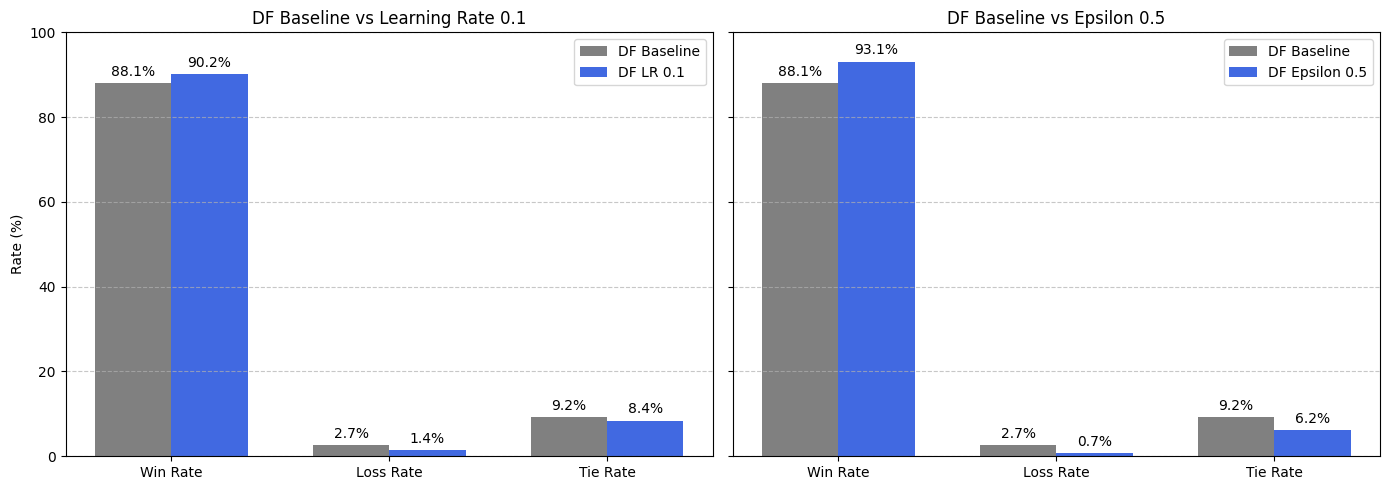

In [ ]:
df_selected = mc_df_results_df.set_index("experiment")
df_base_result = df_selected.loc["df_base"]
df_lr_result = df_selected.loc["df_lr_0.1"]
df_epsilon_result = df_selected.loc["df_eps_0.5"]

metrics = ["win_rate", "loss_rate", "tie_rate"]
metric_labels = ["Win Rate", "Loss Rate", "Tie Rate"]
x = np.arange(len(metrics))
width = 0.35


def plot_df_comparison(ax, adjusted_result, adjusted_label, title):
    baseline_bars = ax.bar(
        x - width / 2,
        df_base_result[metrics],
        width,
        label="DF Baseline",
        color="gray"
    )
    adjusted_bars = ax.bar(
        x + width / 2,
        adjusted_result[metrics],
        width,
        label=adjusted_label,
        color="royalblue"
    )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.bar_label(baseline_bars, fmt="%.1f%%", padding=3)
    ax.bar_label(adjusted_bars, fmt="%.1f%%", padding=3)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_df_comparison(
    axes[0],
    df_lr_result,
    "DF LR 0.1",
    "DF Baseline vs Learning Rate 0.1"
)
plot_df_comparison(
    axes[1],
    df_epsilon_result,
    "DF Epsilon 0.5",
    "DF Baseline vs Epsilon 0.5"
)

axes[0].set_ylabel("Rate (%)")
plt.tight_layout()
plt.show()

## Optional DF-Active Combined Experiment

The strongest individual DF learning-rate and epsilon settings are combined to test whether their improvements remain beneficial when applied together.

In [ ]:
DF_COMBINED_FILE = MC_DF_MODELS_PATH / "df_lr_0.1_eps_0.5.pkl"
df_combined_name = "lr_0.1_eps_0.5"

df_combined_agent, df_combined_result = run_mc_df_experiment(
    name=df_combined_name,
    filepath=DF_COMBINED_FILE,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon=0.5,
    episodes=100000
)

mc_df_agents[df_combined_result["experiment"]] = df_combined_agent

mc_df_results = list({
    result["experiment"]: result
    for result in mc_df_results + [df_combined_result]
}.values())
mc_df_results_df = pd.DataFrame(mc_df_results)

selected_df_names = [
    "df_base",
    "df_lr_0.1",
    "df_eps_0.5",
    "df_lr_0.1_eps_0.5"
]
df_combined_comparison = mc_df_results_df[
    mc_df_results_df["experiment"].isin(selected_df_names)
].copy()

df_combined_comparison["experiment"] = pd.Categorical(
    df_combined_comparison["experiment"],
    categories=selected_df_names,
    ordered=True
)
df_combined_comparison = df_combined_comparison.sort_values("experiment")

combined_columns = [
    "experiment",
    "learning_rate",
    "discount_factor",
    "epsilon",
    "episodes",
    "states",
    "win_rate",
    "loss_rate",
    "tie_rate"
]

display(df_combined_comparison[combined_columns])

mc_df_results_df.to_csv(
    MC_DF_RESULTS_PATH / "mc_df_results.csv",
    index=False
)

Random seed set to: 42


100%|██████████| 100000/100000 [00:04<00:00, 21804.01it/s]

Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/monte_carlo/discount_factor_investigation/df_lr_0.1_eps_0.5.pkl


,experiment,learning_rate,discount_factor,epsilon,episodes,states,win_rate,loss_rate,tie_rate
0,df_base,0.001,0.99,0.1,100000,3966,88.1,2.7,9.2
3,df_lr_0.1,0.100,0.99,0.1,100000,4286,90.2,1.4,8.4
9,df_eps_0.5,0.001,0.99,0.5,100000,4520,93.1,0.7,6.2
13,df_lr_0.1_eps_0.5,0.100,0.99,0.5,100000,4520,97.9,0.0,2.1


### Combined DF-Active Result

Combining `learning_rate=0.1` and `epsilon=0.5` achieved 97.9% wins, 0.0% losses and 2.1% ties.

This combination outperformed either adjustment individually. However, it did not achieve the highest win rate across all DF-active experiments: `gamma=0.1` reached 98.2% wins with 0.3% losses. The combined configuration instead achieved zero observed losses in this evaluation.

One possible explanation is that broader exploration and larger updates interacted more favorably with active discounting. This single seeded experiment does not establish the mechanism or guarantee the same outcome across runs.

## Learning-Rate Convergence and Stability

To evaluate convergence speed and stability, each learning rate is trained for 100,000 episodes and evaluated after every 10,000 episodes. The supplied and DF-active implementations use the same seeds and evaluation opponent.

In [ ]:
MC_CONVERGENCE_PATH = MC_RESULTS_PATH / "convergence"
MC_CONVERGENCE_PATH.mkdir(parents=True, exist_ok=True)

MC_OFFICIAL_CONVERGENCE_FILE = MC_CONVERGENCE_PATH / "official_lr_convergence.csv"
MC_DF_CONVERGENCE_FILE = MC_CONVERGENCE_PATH / "df_active_lr_convergence.csv"
MC_CONVERGENCE_LEARNING_RATES = [0.0001, 0.001, 0.01, 0.1]


def run_mc_learning_rate_convergence(
    agent_class,
    implementation_name,
    learning_rates,
    total_episodes=100000,
    checkpoint_size=10000,
    evaluation_games=1000,
    training_seed=SEED,
    evaluation_seed=2026
):
    assert total_episodes % checkpoint_size == 0
    convergence_rows = []

    for learning_rate_value in learning_rates:
        print(f"\nTraining {implementation_name} | LR={learning_rate_value}")
        set_seed(training_seed)

        agent = agent_class(
            size=BOARD_SIZE,
            learning_rate=learning_rate_value,
            discount_factor=0.99,
            epsilon=0.1
        )

        for episodes_completed in range(
            checkpoint_size,
            total_episodes + checkpoint_size,
            checkpoint_size
        ):
            agent.train(checkpoint_size)
            evaluation = evaluate_mc_agent(
                agent,
                num_games=evaluation_games,
                seed=evaluation_seed
            )

            convergence_rows.append({
                "implementation": implementation_name,
                "learning_rate": learning_rate_value,
                "episodes": episodes_completed,
                "states": len(agent.q_table),
                "evaluation_games": evaluation_games,
                "wins": evaluation["wins"],
                "losses": evaluation["losses"],
                "ties": evaluation["ties"],
                "win_rate": evaluation["win_rate"],
                "loss_rate": evaluation["loss_rate"],
                "tie_rate": evaluation["tie_rate"]
            })

            print(
                f"{episodes_completed:,} episodes | "
                f"Win: {evaluation['win_rate']:.1f}% | "
                f"Loss: {evaluation['loss_rate']:.1f}% | "
                f"Tie: {evaluation['tie_rate']:.1f}%"
            )

    convergence_df = pd.DataFrame(convergence_rows)
    expected_rows = len(learning_rates) * (total_episodes // checkpoint_size)

    assert len(convergence_df) == expected_rows
    assert (
        convergence_df["wins"]
        + convergence_df["losses"]
        + convergence_df["ties"]
        == evaluation_games
    ).all()

    return convergence_df


def load_or_run_mc_convergence(agent_class, implementation_name, filepath):
    if should_train(filepath):
        convergence_df = run_mc_learning_rate_convergence(
            agent_class=agent_class,
            implementation_name=implementation_name,
            learning_rates=MC_CONVERGENCE_LEARNING_RATES
        )
        convergence_df.to_csv(filepath, index=False)
        print(f"Convergence results saved: {filepath}")
    else:
        convergence_df = pd.read_csv(filepath)
        print(f"Convergence results loaded: {filepath}")

    return convergence_df


mc_official_convergence_df = load_or_run_mc_convergence(
    TicTacToeMonteCarlo,
    "Official MC",
    MC_OFFICIAL_CONVERGENCE_FILE
)
mc_df_convergence_df = load_or_run_mc_convergence(
    TicTacToeMonteCarloDF,
    "DF-Active MC",
    MC_DF_CONVERGENCE_FILE
)

mc_convergence_df = pd.concat(
    [mc_official_convergence_df, mc_df_convergence_df],
    ignore_index=True
)

expected_learning_rates = set(MC_CONVERGENCE_LEARNING_RATES)
assert set(mc_official_convergence_df["learning_rate"]) == expected_learning_rates
assert set(mc_df_convergence_df["learning_rate"]) == expected_learning_rates
assert len(mc_official_convergence_df) == 40
assert len(mc_df_convergence_df) == 40


Training Official MC | LR=0.0001
Random seed set to: 42


100%|██████████| 10000/10000 [00:00<00:00, 26498.61it/s]


10,000 episodes | Win: 80.3% | Loss: 5.3% | Tie: 14.4%


100%|██████████| 10000/10000 [00:00<00:00, 28061.65it/s]


20,000 episodes | Win: 83.3% | Loss: 2.5% | Tie: 14.2%


...

80,000 episodes | Win: 92.1% | Loss: 0.0% | Tie: 7.9%


100%|██████████| 10000/10000 [00:00<00:00, 16382.66it/s]


90,000 episodes | Win: 95.4% | Loss: 0.9% | Tie: 3.7%


100%|██████████| 10000/10000 [00:00<00:00, 15039.74it/s]


100,000 episodes | Win: 90.2% | Loss: 1.4% | Tie: 8.4%
Convergence results saved: /content/drive/MyDrive/Projects/Project 4/results/monte_carlo/convergence/df_active_lr_convergence.csv


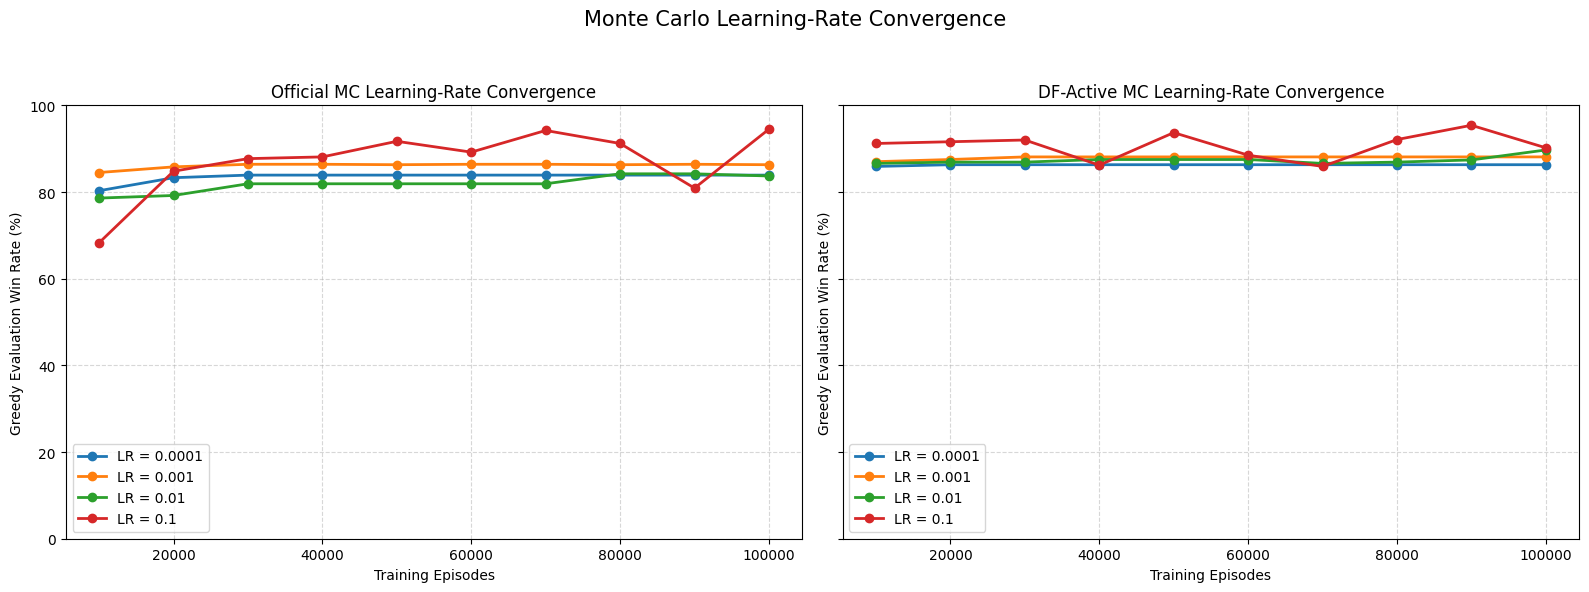

,implementation,learning_rate,final_win_rate,best_win_rate,best_episode,final_states,last_5_checkpoints_std
0,DF-Active MC,0.0001,86.3,86.3,20000,4000,0.00
1,DF-Active MC,0.0010,88.1,88.1,30000,3966,0.00
2,DF-Active MC,0.0100,89.7,89.7,100000,3933,1.09
3,DF-Active MC,0.1000,90.2,95.4,90000,4286,3.22
4,Official MC,0.0001,83.9,83.9,30000,3994,0.00
5,Official MC,0.0010,86.3,86.4,30000,3981,0.05
6,Official MC,0.0100,83.7,84.2,80000,4073,1.06
7,Official MC,0.1000,94.5,94.5,100000,4276,4.96


In [ ]:
learning_rate_colors = {
    0.0001: "tab:blue",
    0.001: "tab:orange",
    0.01: "tab:green",
    0.1: "tab:red"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

for implementation_name, ax in zip(
    ["Official MC", "DF-Active MC"],
    axes
):
    implementation_df = mc_convergence_df[
        mc_convergence_df["implementation"] == implementation_name
    ]

    for learning_rate_value in MC_CONVERGENCE_LEARNING_RATES:
        line_df = implementation_df[
            implementation_df["learning_rate"] == learning_rate_value
        ].sort_values("episodes")

        ax.plot(
            line_df["episodes"],
            line_df["win_rate"],
            marker="o",
            linewidth=2,
            color=learning_rate_colors[learning_rate_value],
            label=f"LR = {learning_rate_value}"
        )

    ax.set_title(f"{implementation_name} Learning-Rate Convergence")
    ax.set_xlabel("Training Episodes")
    ax.set_ylabel("Greedy Evaluation Win Rate (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

fig.suptitle("Monte Carlo Learning-Rate Convergence", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

convergence_summary = []

for (implementation, learning_rate), group in mc_convergence_df.groupby(
    ["implementation", "learning_rate"]
):
    group = group.sort_values("episodes")
    final_row = group.iloc[-1]
    best_row = group.loc[group["win_rate"].idxmax()]

    convergence_summary.append({
        "implementation": implementation,
        "learning_rate": learning_rate,
        "final_win_rate": final_row["win_rate"],
        "best_win_rate": best_row["win_rate"],
        "best_episode": int(best_row["episodes"]),
        "final_states": int(final_row["states"]),
        "last_5_checkpoints_std": group.tail(5)["win_rate"].std(ddof=0)
    })

mc_convergence_summary_df = pd.DataFrame(convergence_summary).sort_values(
    ["implementation", "learning_rate"]
)

display(mc_convergence_summary_df.round({
    "final_win_rate": 2,
    "best_win_rate": 2,
    "last_5_checkpoints_std": 2
}))

### Convergence and Stability Discussion

In the supplied implementation, learning rates `0.0001` and `0.001` reached relatively stable plateaus with weaker final performance. Learning rate `0.1` started below the other settings at the first checkpoint, but later achieved the highest final win rate, 94.5%. It also showed the greatest late-training variation, with a final-five-checkpoint standard deviation of 4.96.

In the DF-active implementation, learning rate `0.001` stabilized at 88.1%, while `0.01` finished at 89.7%. Learning rate `0.1` reached 95.4% at its best checkpoint, but finished at 90.2%, with a late-training standard deviation of 3.22.

The main observed trade-off is between stronger performance and greater variation, not a universal improvement in convergence speed. Checkpoint win rates and their standard deviation describe evaluated performance, not formal convergence of the Q-values.

## Question 1 - Conclusion

The required Monte Carlo experiments showed that learning rate and epsilon had the clearest effects on final performance. `learning_rate=0.1` achieved the strongest supplied-policy result, while `epsilon=0.5` improved exploration and state coverage. Increasing training beyond 50,000 episodes produced diminishing performance gains.

The supplied discount factor had no effect because it was not used in the update. The separate DF-active implementation confirmed that gamma can substantially change the learned policy and its interaction with other hyperparameters.

The convergence analysis showed a performance-stability trade-off: the larger learning rate achieved higher peaks with greater variation, while smaller learning rates produced smoother but weaker plateaus.

# 2. Q Learning
Train your player using Q-learning. Update the Q-values using the Bellman equation.

Bellman equation used to update the q values:

$$Q(s, a) = Q(s, a) + \alpha[ r + \gamma \max_{a'}Q(s', a') - Q(s, a)]$$

An Epsilon-Greedy strategy is employed to choose subsequent actions.

# Epsilon-Greedy Action Selection in Q-Learning
1. state_to_str(state): This function is designed to convert the game's state into a string, which serves as a dictionary key. It takes the state (likely a list or array) and concatenates all its elements into a single string. This string representation of the state is essential for storing and retrieving corresponding Q-values in the Q-table efficiently.
2. select_action(state, moves, epsilon): This function implements the epsilon-greedy policy to select the next action. It first converts the current state into a string using the state_to_str function. The action selection process then follows two paths based on a random number compared to the epsilon threshold:
Exploration: With a probability of epsilon, it selects a random action

  *   Exploration: With a probability of epsilon, it selects a random action from the list of available moves. This randomness introduces necessary exploration, allowing the algorithm to discover new strategies.
  * Exploitation: If the random number is above the epsilon threshold, the function proceeds to exploit known information. It checks if the state string exists in the Q-table. If not, a random action is chosen since no learned values exist. If the state is known, it filters the Q-table entries for that state to include only those actions that are available (moves). It then selects the action with the highest Q-value among these filtered entries, enabling the algorithm to use the best-known strategy based on past learning.

In [6]:
def state_to_str(state):
    return "".join(state)


def select_action(state, moves, epsilon):
    state_str = state_to_str(state)

    if np.random.rand() < epsilon:
        return random.choice(moves)

    if state_str not in q_table:
        return random.choice(moves)

    legal_q_values = [
        (action, value)
        for action, value in q_table[state_str].items()
        if action in moves
    ]
    return max(legal_q_values, key=lambda item: item[1])[0]

## 2.a - Complete the Q-Table Update

In [7]:
def update_q_table(
    state,
    action,
    reward,
    next_state,
    moves,
    learning_rate,
    discount_factor
):
    state_str = state_to_str(state)
    next_state_str = state_to_str(next_state)

    if state_str not in q_table:
        q_table[state_str] = {
            action: 0
            for action in game.total_moves()
        }

    if next_state_str not in q_table:
        q_table[next_state_str] = {
            action: 0
            for action in game.total_moves()
        }

    max_next_action = max(
        q_table[next_state_str],
        key=q_table[next_state_str].get
    )

    q_table[state_str][action] += learning_rate * (
        reward
        + discount_factor * q_table[next_state_str][max_next_action]
        - q_table[state_str][action]
    )

### 2.a - Bellman Update

The supplied function implements:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\right]$$

The TD target, $r+\gamma\max_{a'}Q(s',a')$, combines the immediate reward with the discounted estimate of the best next action. Its difference from the current value is the TD error.

The learning rate $\alpha$ controls the size of each update, while the discount factor $\gamma$ controls the importance of future value. Unlike Monte Carlo, which updates after a complete episode, Q-learning bootstraps from the estimated next-state value after each transition.

#### Training the agent with Q-learning

In [8]:
def train(episodes, epsilon, epsilon_min, epsilon_decay):
    number_of_agent_actions = []
    number_of_random_actions = []
    game_result = []
    epsilon_convergence = []

    for _ in tqdm(range(episodes)):
        agent_action, random_action = 0, 0
        result = ""
        game = TicTacToe(size)
        current_state = game.board.copy()
        letter = player_1

        while game.empty_squares():
            moves = game.available_moves()

            if letter == player_2:
                random_action += 1
                square = random.choice(moves)
            else:
                agent_action += 1
                square = select_action(current_state, moves, epsilon)

            next_state = game.make_move(square, letter)

            if game.current_winner:
                if letter == player_1:
                    reward = win_reward
                    result = "win"
                else:
                    reward = lose_reward
                    result = "loss"
                break
            elif not game.empty_squares():
                reward = tie_reward
                result = "tie"
            else:
                reward = step_reward

            update_q_table(
                current_state,
                square,
                reward,
                next_state,
                moves,
                learning_rate,
                discount_factor
            )

            current_state = next_state.copy()
            letter = player_2 if letter == player_1 else player_1

        epsilon_convergence.append(epsilon)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        number_of_agent_actions.append(agent_action)
        number_of_random_actions.append(random_action)
        game_result.append(result)

    return (
        number_of_agent_actions,
        number_of_random_actions,
        game_result,
        epsilon_convergence
    )

## Additional Q-Learning Correction

The supplied 2.a implementation is preserved above. However, its training flow has three structural limitations:

1. It updates the shared Q-table after both X and the random opponent O.
2. A terminal win or loss reaches `break` before the final update.
3. The Bellman maximum includes occupied actions rather than only legal next actions.

The corrected implementation treats one agent transition as:

$$s_X \rightarrow a_X \rightarrow \text{O response} \rightarrow s'_X$$

Only X's action is updated. If O wins, the loss is assigned to the preceding X decision. Terminal transitions use $Q(s,a)\leftarrow Q(s,a)+\alpha[r-Q(s,a)]$; non-terminal transitions bootstrap only from legal actions in the next X state.

In [9]:
def update_q_table_corrected(
    state,
    action,
    reward,
    next_state,
    next_moves,
    learning_rate,
    discount_factor,
    done
):
    state_str = state_to_str(state)

    if state_str not in q_table:
        q_table[state_str] = {
            action: 0
            for action in game.total_moves()
        }

    if action not in q_table[state_str]:
        q_table[state_str][action] = 0

    if done:
        td_target = reward
    else:
        next_state_str = state_to_str(next_state)

        if next_state_str not in q_table:
            q_table[next_state_str] = {
                action: 0
                for action in game.total_moves()
            }

        legal_q_values = [
            q_table[next_state_str][action]
            for action in next_moves
        ]
        max_next_q = max(legal_q_values) if legal_q_values else 0
        td_target = reward + discount_factor * max_next_q

    q_table[state_str][action] += learning_rate * (
        td_target - q_table[state_str][action]
    )


def train_q_corrected(episodes, epsilon, epsilon_min, epsilon_decay):
    number_of_agent_actions = []
    number_of_random_actions = []
    game_result = []
    epsilon_convergence = []

    for _ in tqdm(range(episodes)):
        agent_action, random_action = 0, 0
        result = ""
        local_game = TicTacToe(size)

        while local_game.empty_squares():
            current_state = local_game.board.copy()
            moves = local_game.available_moves()
            square = select_action(current_state, moves, epsilon)

            local_game.make_move(square, "X")
            agent_action += 1

            if local_game.current_winner == "X":
                result = "win"
                update_q_table_corrected(
                    current_state,
                    square,
                    win_reward,
                    None,
                    None,
                    learning_rate,
                    discount_factor,
                    True
                )
                break

            if not local_game.empty_squares():
                result = "tie"
                update_q_table_corrected(
                    current_state,
                    square,
                    tie_reward,
                    None,
                    None,
                    learning_rate,
                    discount_factor,
                    True
                )
                break

            o_moves = local_game.available_moves()
            o_square = random.choice(o_moves)
            local_game.make_move(o_square, "O")
            random_action += 1

            if local_game.current_winner == "O":
                result = "loss"
                update_q_table_corrected(
                    current_state,
                    square,
                    lose_reward,
                    None,
                    None,
                    learning_rate,
                    discount_factor,
                    True
                )
                break

            if not local_game.empty_squares():
                result = "tie"
                update_q_table_corrected(
                    current_state,
                    square,
                    tie_reward,
                    None,
                    None,
                    learning_rate,
                    discount_factor,
                    True
                )
                break

            next_state = local_game.board.copy()
            next_moves = local_game.available_moves()
            update_q_table_corrected(
                current_state,
                square,
                step_reward,
                next_state,
                next_moves,
                learning_rate,
                discount_factor,
                False
            )

        epsilon_convergence.append(epsilon)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        number_of_agent_actions.append(agent_action)
        number_of_random_actions.append(random_action)
        game_result.append(result)

    return (
        number_of_agent_actions,
        number_of_random_actions,
        game_result,
        epsilon_convergence
    )

## Q-Learning Baseline

The corrected agent is trained for 1,000,000 episodes with the baseline configuration. Existing Q-table and training-history artifacts are loaded automatically when available.

In [10]:
Q_BASELINE_CONFIG = {
    "learning_rate": 0.001,
    "discount_factor": 0.99,
    "epsilon": 1.0,
    "epsilon_decay": 0.995,
    "epsilon_min": 0.01,
    "episodes": 1000000,
    "win_reward": 1,
    "lose_reward": 0,
    "tie_reward": 0,
    "step_reward": 0.0001
}

size = BOARD_SIZE
learning_rate = Q_BASELINE_CONFIG["learning_rate"]
discount_factor = Q_BASELINE_CONFIG["discount_factor"]
epsilon = Q_BASELINE_CONFIG["epsilon"]
epsilon_decay = Q_BASELINE_CONFIG["epsilon_decay"]
epsilon_min = Q_BASELINE_CONFIG["epsilon_min"]
episodes = Q_BASELINE_CONFIG["episodes"]
win_reward = Q_BASELINE_CONFIG["win_reward"]
lose_reward = Q_BASELINE_CONFIG["lose_reward"]
tie_reward = Q_BASELINE_CONFIG["tie_reward"]
step_reward = Q_BASELINE_CONFIG["step_reward"]

player_1 = "X"
player_2 = "O"
game = TicTacToe(size)

Q_MODEL_FILE = Q_BASELINE_MODELS_PATH / "q_corrected_1m.pkl"
Q_STATS_FILE = Q_BASELINE_RESULTS_PATH / "q_corrected_1m.csv"

set_seed(SEED)

if should_train(Q_MODEL_FILE) or not Q_STATS_FILE.exists():
    q_table = {}

    (
        number_of_agent_actions,
        number_of_random_actions,
        episode_results,
        epsilon_convergence
    ) = train_q_corrected(
        episodes,
        epsilon,
        epsilon_min,
        epsilon_decay
    )

    q_training_df = pd.DataFrame({
        "agent_actions": number_of_agent_actions,
        "random_actions": number_of_random_actions,
        "epsilon": epsilon_convergence,
        "result": episode_results
    })

    save_pickle(q_table, Q_MODEL_FILE)
    q_training_df.to_csv(Q_STATS_FILE, index=False)
    print(f"Training statistics saved: {Q_STATS_FILE}")
else:
    q_table = load_pickle(Q_MODEL_FILE)
    q_training_df = pd.read_csv(Q_STATS_FILE)

    number_of_agent_actions = q_training_df["agent_actions"].tolist()
    number_of_random_actions = q_training_df["random_actions"].tolist()
    epsilon_convergence = q_training_df["epsilon"].tolist()
    episode_results = q_training_df["result"].tolist()
    print(f"Training statistics loaded: {Q_STATS_FILE}")

print(f"Q-table artifact: {Q_MODEL_FILE}")
print(f"Training statistics artifact: {Q_STATS_FILE}")
print(f"States in Q-table: {len(q_table)}")
print(f"Stored episodes: {len(q_training_df)}")

Random seed set to: 42
Artifact loaded: /content/drive/MyDrive/Projects/Project 4/saved_models/q_learning/baseline/q_corrected_1m.pkl
Training statistics loaded: /content/drive/MyDrive/Projects/Project 4/results/q_learning/baseline/q_corrected_1m.csv
Q-table artifact: /content/drive/MyDrive/Projects/Project 4/saved_models/q_learning/baseline/q_corrected_1m.pkl
Training statistics artifact: /content/drive/MyDrive/Projects/Project 4/results/q_learning/baseline/q_corrected_1m.csv
States in Q-table: 1417
Stored episodes: 1000000


### Training Action Distribution

The histogram shows how many actions the Q-learning agent selected per training episode.

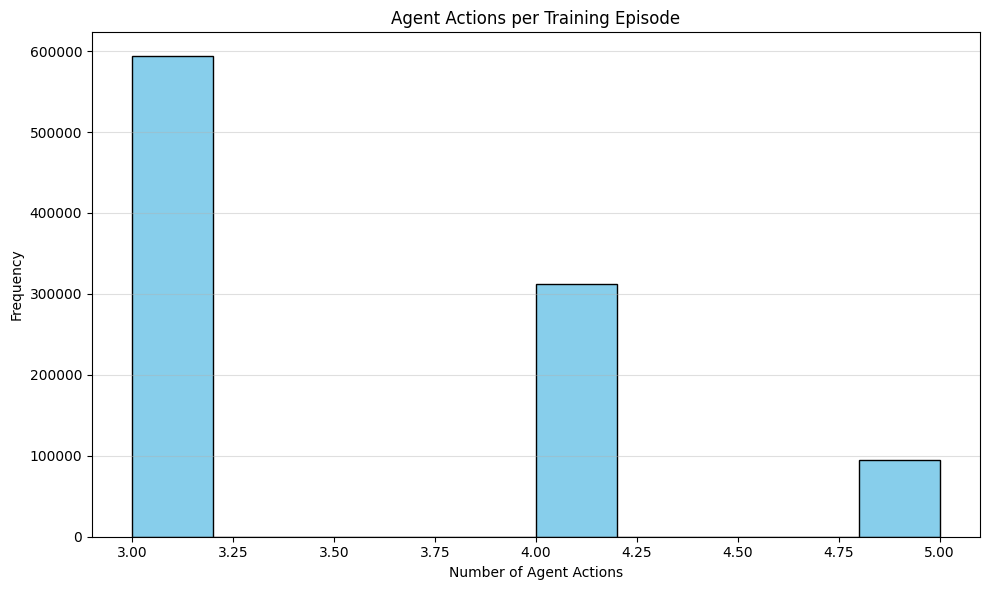

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    number_of_agent_actions,
    bins=10,
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("Number of Agent Actions")
plt.ylabel("Frequency")
plt.title("Agent Actions per Training Episode")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## 2.b - Baseline Evaluation and Reusable Plots

The corrected baseline Q-learning agent is evaluated over 1,000 games. We also define a helper function to visualize evaluation metrics across different hyperparameter settings.

### Evaluation Scope

All reported Q-learning evaluations use the same controlled setting: the trained agent plays as X, always makes the first move, and is evaluated against a random opponent playing as O. The evaluation policy is greedy except when the current state was not encountered during training.

Therefore, the reported win, loss, and tie rates measure performance under this specific setting. They do not measure performance against an optimal opponent or when the trained agent plays second.

In [ ]:
def select_greedy_q_action(table, state, moves, rng):
    """Select the highest-valued legal action."""
    state_str = state_to_str(state)

    if state_str not in table:
        return rng.choice(moves)

    legal_q_values = [
        (action, table[state_str].get(action, 0))
        for action in moves
    ]
    return max(legal_q_values, key=lambda item: item[1])[0]


def evaluate_q_table(table, num_games=1000, seed=2026):
    """Evaluate agent X greedily against a random opponent O."""
    rng = random.Random(seed)
    wins = losses = ties = 0

    for _ in range(num_games):
        evaluation_game = TicTacToe(BOARD_SIZE)

        while evaluation_game.empty_squares():
            state = evaluation_game.board.copy()
            moves = evaluation_game.available_moves()

            x_action = select_greedy_q_action(
                table, state, moves, rng
            )
            evaluation_game.make_move(x_action, "X")

            if evaluation_game.current_winner == "X":
                wins += 1
                break

            if not evaluation_game.empty_squares():
                ties += 1
                break

            o_action = rng.choice(evaluation_game.available_moves())
            evaluation_game.make_move(o_action, "O")

            if evaluation_game.current_winner == "O":
                losses += 1
                break

            if not evaluation_game.empty_squares():
                ties += 1
                break

    assert wins + losses + ties == num_games

    return {
        "evaluation_games": num_games,
        "wins": wins,
        "losses": losses,
        "ties": ties,
        "win_rate": 100 * wins / num_games,
        "loss_rate": 100 * losses / num_games,
        "tie_rate": 100 * ties / num_games
    }


def plot_q_evaluation_comparison(
    results_list,
    title="Q-Learning Evaluation Comparison"
):
    df = pd.DataFrame(results_list)
    metrics = ["win_rate", "loss_rate", "tie_rate"]
    labels = ["Win Rate", "Loss Rate", "Tie Rate"]

    x = np.arange(len(labels))
    width = 0.8 / len(df)
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, row in df.iterrows():
        positions = x + (i - len(df) / 2 + 0.5) * width
        ax.bar(
            positions,
            row[metrics].astype(float),
            width,
            label=row["experiment"]
        )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Rate (%)")
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


baseline_q_results = evaluate_q_table(
    q_table,
    num_games=1000,
    seed=2026
)

baseline_q_results.update({
    "experiment": "baseline",
    "learning_rate": Q_BASELINE_CONFIG["learning_rate"],
    "discount_factor": Q_BASELINE_CONFIG["discount_factor"],
    "initial_epsilon": Q_BASELINE_CONFIG["epsilon"],
    "epsilon_decay": Q_BASELINE_CONFIG["epsilon_decay"],
    "epsilon_min": Q_BASELINE_CONFIG["epsilon_min"],
    "episodes": Q_BASELINE_CONFIG["episodes"],
    "win_reward": Q_BASELINE_CONFIG["win_reward"],
    "lose_reward": Q_BASELINE_CONFIG["lose_reward"],
    "tie_reward": Q_BASELINE_CONFIG["tie_reward"],
    "step_reward": Q_BASELINE_CONFIG["step_reward"],
    "states": len(q_table)
})

print("Corrected Q-learning baseline evaluation")
display(pd.DataFrame([baseline_q_results]))

Corrected Q-learning baseline evaluation


,evaluation_games,wins,losses,ties,win_rate,loss_rate,tie_rate,experiment,learning_rate,discount_factor,initial_epsilon,epsilon_decay,epsilon_min,episodes,win_reward,lose_reward,tie_reward,step_reward,states
0,1000,845,127,28,84.5,12.7,2.8,baseline,0.001,0.99,1.0,0.995,0.01,1000000,1,0,0,0.0001,1417


## 2.b-f: Q-Learning Experiment Infrastructure

The following functions provide a shared training, history, evaluation, and artifact-saving pipeline for all Q-learning experiments.

In [ ]:
def select_action_from_table(table, state, moves, epsilon):
    state_str = state_to_str(state)

    if np.random.rand() < epsilon or state_str not in table:
        return random.choice(moves)

    legal_q = {
        action: table[state_str][action]
        for action in moves
        if action in table[state_str]
    }

    if not legal_q:
        return random.choice(moves)

    return max(legal_q, key=legal_q.get)


def update_q_table_for_table(
    table,
    state,
    action,
    reward,
    next_state,
    next_moves,
    learning_rate,
    discount_factor,
    done
):
    state_str = state_to_str(state)

    if state_str not in table:
        table[state_str] = {
            action: 0 for action in range(ACTION_SIZE)
        }

    if done:
        td_target = reward
    else:
        next_state_str = state_to_str(next_state)

        if next_state_str not in table:
            table[next_state_str] = {
                action: 0 for action in range(ACTION_SIZE)
            }

        legal_q_values = [
            table[next_state_str][action]
            for action in next_moves
        ]
        max_next_q = max(legal_q_values) if legal_q_values else 0
        td_target = reward + discount_factor * max_next_q

    table[state_str][action] += learning_rate * (
        td_target - table[state_str][action]
    )


def train_q_with_history(config, checkpoint_interval=10000):
    local_q_table = {}
    history = []
    window_wins = window_losses = window_ties = 0
    window_actions = []
    current_epsilon = config["epsilon"]

    for episode in tqdm(range(1, config["episodes"] + 1)):
        local_game = TicTacToe(BOARD_SIZE)
        agent_actions = 0

        while local_game.empty_squares():
            state = local_game.board.copy()
            moves = local_game.available_moves()
            action = select_action_from_table(
                local_q_table,
                state,
                moves,
                current_epsilon
            )

            local_game.make_move(action, "X")
            agent_actions += 1

            if local_game.current_winner == "X":
                reward = config["win_reward"]
                window_wins += 1
                done = True
            elif not local_game.empty_squares():
                reward = config["tie_reward"]
                window_ties += 1
                done = True
            else:
                o_action = random.choice(
                    local_game.available_moves()
                )
                local_game.make_move(o_action, "O")

                if local_game.current_winner == "O":
                    reward = config["lose_reward"]
                    window_losses += 1
                    done = True
                elif not local_game.empty_squares():
                    reward = config["tie_reward"]
                    window_ties += 1
                    done = True
                else:
                    reward = config["step_reward"]
                    done = False

            if done:
                update_q_table_for_table(
                    local_q_table,
                    state,
                    action,
                    reward,
                    None,
                    None,
                    config["learning_rate"],
                    config["discount_factor"],
                    True
                )
                break

            next_state = local_game.board.copy()
            next_moves = local_game.available_moves()

            update_q_table_for_table(
                local_q_table,
                state,
                action,
                reward,
                next_state,
                next_moves,
                config["learning_rate"],
                config["discount_factor"],
                False
            )

        window_actions.append(agent_actions)
        current_epsilon = max(
            config["epsilon_min"],
            current_epsilon * config["epsilon_decay"]
        )

        if episode % checkpoint_interval == 0 or episode == config["episodes"]:
            window_size = len(window_actions)

            history.append({
                "episode": episode,
                "epsilon": current_epsilon,
                "states": len(local_q_table),
                "window_win_rate": 100 * window_wins / window_size,
                "window_loss_rate": 100 * window_losses / window_size,
                "window_tie_rate": 100 * window_ties / window_size,
                "avg_agent_actions": np.mean(window_actions),
                "window_wins": window_wins,
                "window_losses": window_losses,
                "window_ties": window_ties
            })

            window_wins = window_losses = window_ties = 0
            window_actions = []

    return local_q_table, pd.DataFrame(history)


def run_q_experiment(name, config):
    model_file = Q_EXPERIMENT_MODELS_PATH / f"{name}.pkl"
    history_file = Q_HISTORY_PATH / f"{name}_history.csv"
    evaluation_file = Q_EVALUATION_PATH / f"{name}_eval.csv"

    set_seed(SEED)

    if should_train(model_file) or not history_file.exists():
        print(f"Training experiment: {name}")
        trained_q, history_df = train_q_with_history(config)

        assert trained_q, (
            f"Experiment {name} produced an empty Q-table."
        )

        save_pickle(trained_q, model_file)
        history_df.to_csv(history_file, index=False)
        print(f"Training history saved: {history_file}")
    else:
        print(f"Loading experiment: {name}")
        trained_q = load_pickle(model_file)
        history_df = pd.read_csv(history_file)

        assert trained_q, (
            f"Loaded Q-table for {name} is empty."
        )

    evaluation = evaluate_q_table(
        trained_q,
        num_games=1000,
        seed=2026
    )

    assert (
        evaluation["wins"]
        + evaluation["losses"]
        + evaluation["ties"]
        == evaluation["evaluation_games"]
        == 1000
    ), f"Invalid evaluation totals for {name}."

    evaluation.update({
        "experiment": name,
        "learning_rate": config["learning_rate"],
        "discount_factor": config["discount_factor"],
        "initial_epsilon": config["epsilon"],
        "epsilon_decay": config["epsilon_decay"],
        "epsilon_min": config["epsilon_min"],
        "episodes": config["episodes"],
        "win_reward": config["win_reward"],
        "lose_reward": config["lose_reward"],
        "tie_reward": config["tie_reward"],
        "step_reward": config["step_reward"],
        "states": len(trained_q)
    })

    pd.DataFrame([evaluation]).to_csv(
        evaluation_file,
        index=False
    )
    print(f"Evaluation saved: {evaluation_file}")

    return trained_q, history_df, evaluation

## 2.b - Learning Rate 0.1

This experiment increases the learning rate from `0.001` to `0.1`. Larger updates may accelerate learning, but can also make Q-values less stable.

Random seed set to: 42
Training experiment: q_lr_0.1_1m


100%|██████████| 1000000/1000000 [00:40<00:00, 24784.38it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/q_learning/experiments/q_lr_0.1_1m.pkl
Training history saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/histories/q_lr_0.1_1m_history.csv
Evaluation saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/evaluations/q_lr_0.1_1m_eval.csv


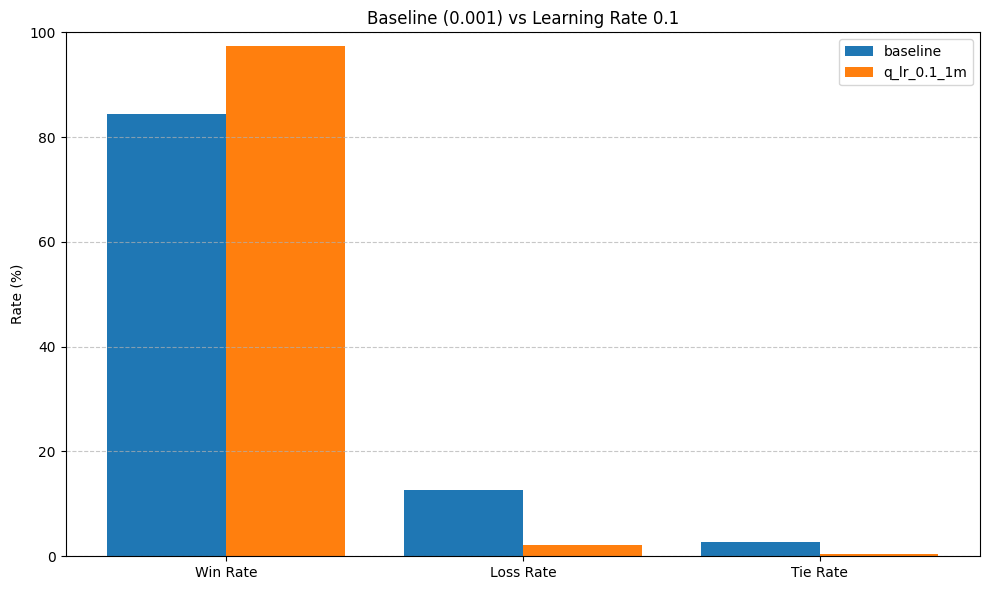

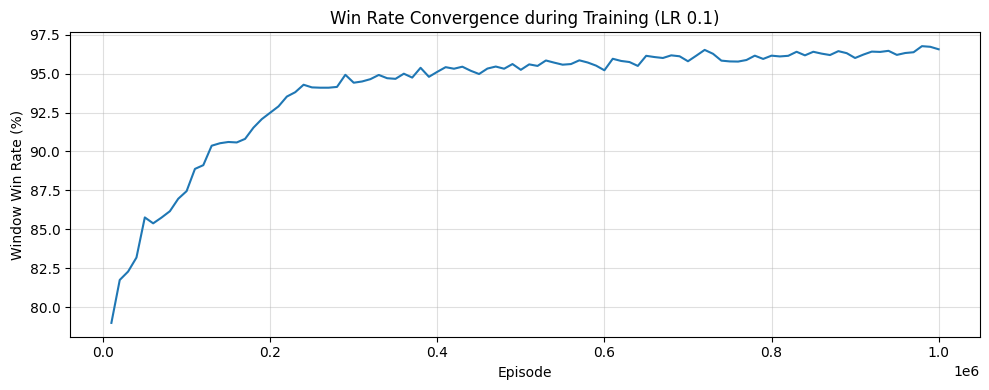

In [ ]:
lr_config = Q_BASELINE_CONFIG.copy()
lr_config["learning_rate"] = 0.1

q_lr_01, hist_lr_01, eval_lr_01 = run_q_experiment(
    "q_lr_0.1_1m",
    lr_config
)

plot_q_evaluation_comparison(
    [baseline_q_results, eval_lr_01],
    title="Baseline (0.001) vs Learning Rate 0.1"
)

plt.figure(figsize=(10, 4))
plt.plot(
    hist_lr_01["episode"],
    hist_lr_01["window_win_rate"]
)
plt.title("Win Rate Convergence during Training (LR 0.1)")
plt.xlabel("Episode")
plt.ylabel("Window Win Rate (%)")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### 2.b - Conclusion

Increasing the learning rate to `0.1` improved the win rate from **84.5%** to **97.4%**, while losses decreased from **12.7%** to **2.2%**. The training curve rose rapidly and remained near 96%–97% toward the end, with no clear late-stage instability.

Under this experiment's fixed seed, reward structure and random opponent, `0.1` performed better than the baseline learning rate. This does not imply that it is universally optimal.

## 2.c - Discount Factors 0.9 and 0.5

The discount factor controls the importance of future Q-values. We compare the baseline `0.99` with `0.9` and `0.5`.

Random seed set to: 42
Training experiment: q_gamma_0.9_1m


100%|██████████| 1000000/1000000 [00:41<00:00, 23980.98it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/q_learning/experiments/q_gamma_0.9_1m.pkl
Training history saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/histories/q_gamma_0.9_1m_history.csv
Evaluation saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/evaluations/q_gamma_0.9_1m_eval.csv
Random seed set to: 42
Training experiment: q_gamma_0.5_1m


100%|██████████| 1000000/1000000 [00:41<00:00, 24032.28it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/q_learning/experiments/q_gamma_0.5_1m.pkl
Training history saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/histories/q_gamma_0.5_1m_history.csv
Evaluation saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/evaluations/q_gamma_0.5_1m_eval.csv


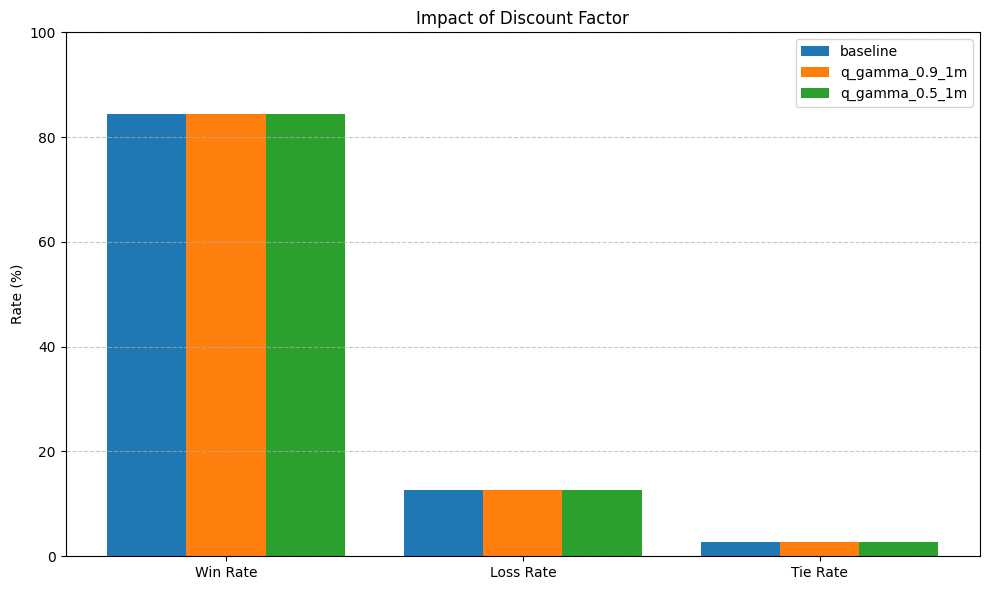

In [ ]:
gamma_09_config = Q_BASELINE_CONFIG.copy()
gamma_09_config["discount_factor"] = 0.9

gamma_05_config = Q_BASELINE_CONFIG.copy()
gamma_05_config["discount_factor"] = 0.5

_, _, eval_g09 = run_q_experiment(
    "q_gamma_0.9_1m",
    gamma_09_config
)
_, _, eval_g05 = run_q_experiment(
    "q_gamma_0.5_1m",
    gamma_05_config
)

plot_q_evaluation_comparison(
    [baseline_q_results, eval_g09, eval_g05],
    title="Impact of Discount Factor"
)

### 2.c - Conclusion

All three discount factors produced the same evaluation rates: **84.5% wins**, **12.7% losses** and **2.8% ties**.

Compared with `gamma=0.99`, `0.9` moderately reduces the weight of future value, while `0.5` discounts it more strongly and emphasizes near-term rewards.

Gamma still changes the Bellman target:

$$
r+\gamma\max_{a'}Q(s',a')
$$

However, this mathematical difference did not translate into different aggregate evaluation rates in these runs. Identical win, loss and tie rates do not establish identical Q-values, action choices or policies.

## 2.d - Epsilon Schedule

The epsilon schedule controls the transition from exploration to exploitation. Because the baseline already starts at `epsilon=1`, no additional training run is required.

,episode,epsilon
0,0,1.000000
1,1,0.995000
2,10,0.951110
3,100,0.605770
4,500,0.081572
5,900,0.010984
6,1000,0.010000
7,10000,0.010000
8,100000,0.010000
9,1000000,0.010000


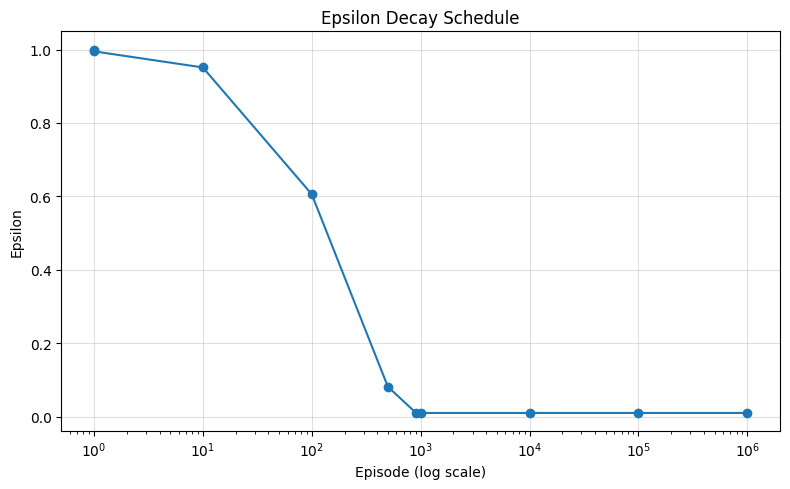

In [ ]:
epsilon_episodes = [
    0, 1, 10, 100, 500,
    900, 1000, 10000, 100000, 1000000
]

epsilon_schedule = [
    (
        episode,
        max(
            Q_BASELINE_CONFIG["epsilon_min"],
            Q_BASELINE_CONFIG["epsilon"]
            * Q_BASELINE_CONFIG["epsilon_decay"] ** episode
        )
    )
    for episode in epsilon_episodes
]

epsilon_schedule_df = pd.DataFrame(
    epsilon_schedule,
    columns=["episode", "epsilon"]
)
display(epsilon_schedule_df)

epsilon_schedule_df["plot_episode"] = (
    epsilon_schedule_df["episode"].clip(lower=1)
)

plt.figure(figsize=(8, 5))
plt.semilogx(
    epsilon_schedule_df["plot_episode"],
    epsilon_schedule_df["epsilon"],
    marker="o"
)
plt.title("Epsilon Decay Schedule")
plt.xlabel("Episode (log scale)")
plt.ylabel("Epsilon")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### 2.d - Interpretation

At `epsilon=1`, every decision is exploratory. Epsilon then falls to approximately `0.606` after 100 episodes, `0.082` after 500 episodes and reaches its minimum of `0.01` near episode 1000.

Most of the one-million-episode training therefore uses a 99% greedy policy while retaining 1% exploration. Keeping epsilon fixed at `1` would prevent the agent from exploiting what it learned.

## 2.e - 10,000,000 Episodes

This experiment tests whether ten times more training improves state coverage and evaluation performance.

Random seed set to: 42
Loading experiment: q_episodes_10m
Artifact loaded: /content/drive/MyDrive/Projects/Project 4/saved_models/q_learning/experiments/q_episodes_10m.pkl
Evaluation saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/evaluations/q_episodes_10m_eval.csv


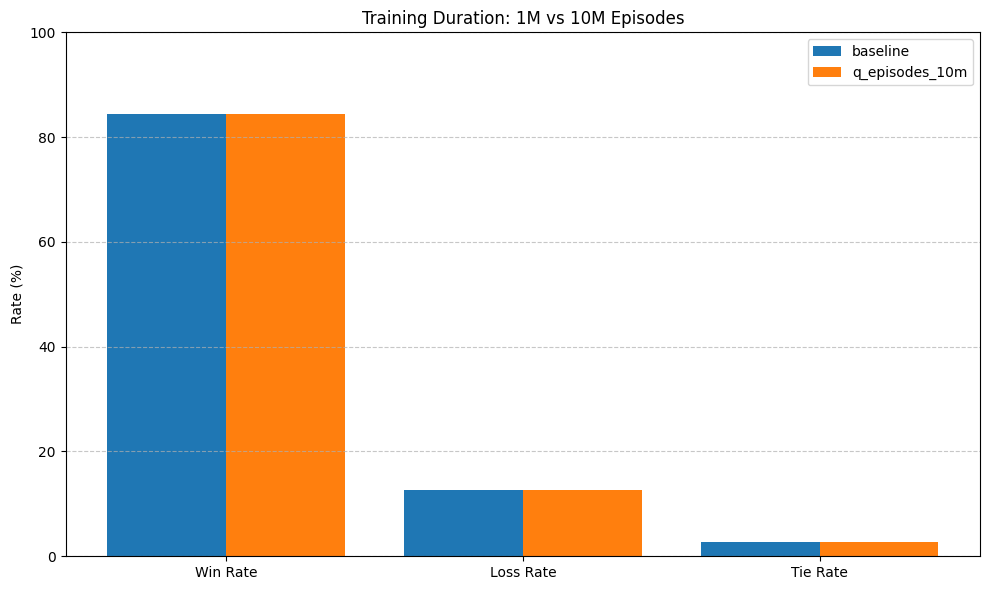

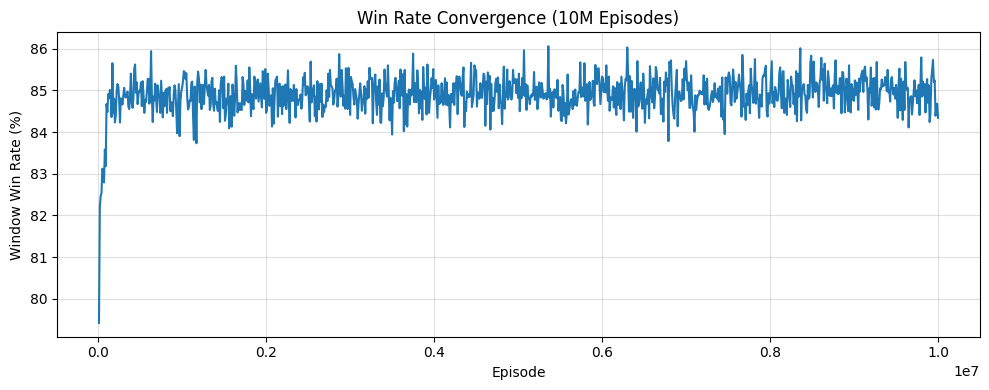

In [ ]:
ep_10m_config = Q_BASELINE_CONFIG.copy()
ep_10m_config["episodes"] = 10000000

q_10m, hist_10m, eval_10m = run_q_experiment(
    "q_episodes_10m",
    ep_10m_config
)

plot_q_evaluation_comparison(
    [baseline_q_results, eval_10m],
    title="Training Duration: 1M vs 10M Episodes"
)

plt.figure(figsize=(10, 4))
plt.plot(
    hist_10m["episode"],
    hist_10m["window_win_rate"]
)
plt.title("Win Rate Convergence (10M Episodes)")
plt.xlabel("Episode")
plt.ylabel("Window Win Rate (%)")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### 2.e - Conclusion

Training for 10 million episodes expanded the Q-table from **1,417** to **1,906 states**, but evaluation remained unchanged at **84.5% wins**, **12.7% losses** and **2.8% ties**.

The training curve showed an early performance plateau. Additional training expanded state coverage without improving the reported evaluation metrics. Identical aggregate rates do not prove that the learned Q-values or selected actions were unchanged.

## 2.f - Negative Tie Reward

This experiment changes the tie reward from `0` to `-0.5` to test whether penalizing draws reduces their frequency.

Random seed set to: 42
Training experiment: q_tie_negative_1m


100%|██████████| 1000000/1000000 [00:40<00:00, 24488.46it/s]


Artifact saved: /content/drive/MyDrive/Projects/Project 4/saved_models/q_learning/experiments/q_tie_negative_1m.pkl
Training history saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/histories/q_tie_negative_1m_history.csv
Evaluation saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/evaluations/q_tie_negative_1m_eval.csv


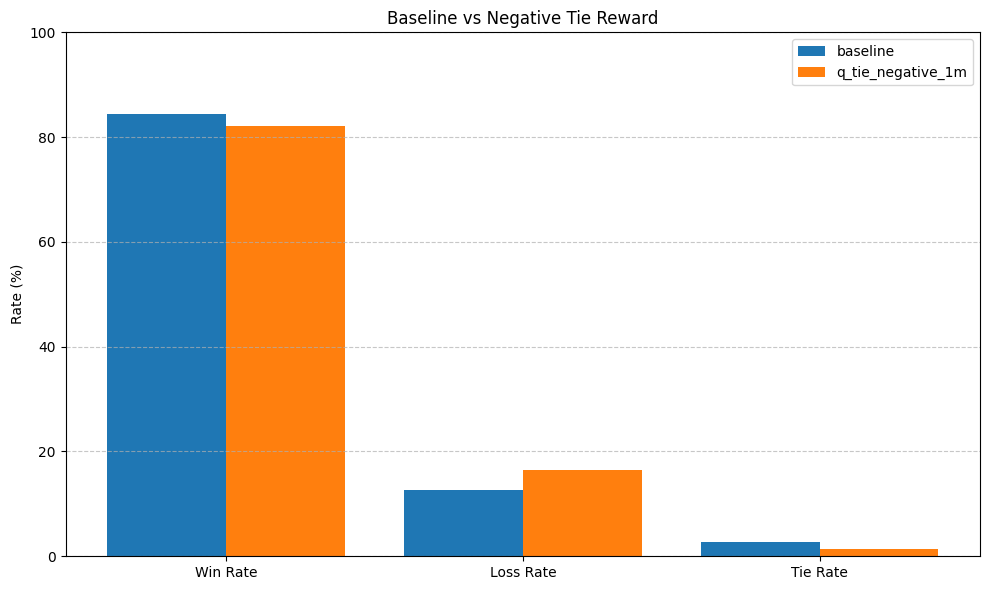

In [ ]:
neg_tie_config = Q_BASELINE_CONFIG.copy()
neg_tie_config["tie_reward"] = -0.5

_, _, eval_neg = run_q_experiment(
    "q_tie_negative_1m",
    neg_tie_config
)

plot_q_evaluation_comparison(
    [baseline_q_results, eval_neg],
    title="Baseline vs Negative Tie Reward"
)

### 2.f - Conclusion

The negative tie reward reduced ties from **2.8%** to **1.4%**, but wins fell from **84.5%** to **82.2%** and losses increased from **12.7%** to **16.4%**.

Since a loss receives `0` while a tie receives `-0.5`, the reward function makes losing preferable to drawing:

$$
R_{\text{win}}=1 > R_{\text{loss}}=0 > R_{\text{tie}}=-0.5
$$

The experiment demonstrates that reward values must represent the intended preference ordering.

## 2.b-f - Experiment Summary

The table and chart consolidate all Q-learning experiments under the same evaluation conditions.

,experiment,states,win_rate,loss_rate,tie_rate
0,baseline,1417,84.5,12.7,2.8
1,q_lr_0.1_1m,1418,97.4,2.2,0.4
2,q_gamma_0.9_1m,1417,84.5,12.7,2.8
3,q_gamma_0.5_1m,1417,84.5,12.7,2.8
4,q_episodes_10m,1906,84.5,12.7,2.8
5,q_tie_negative_1m,1431,82.2,16.4,1.4


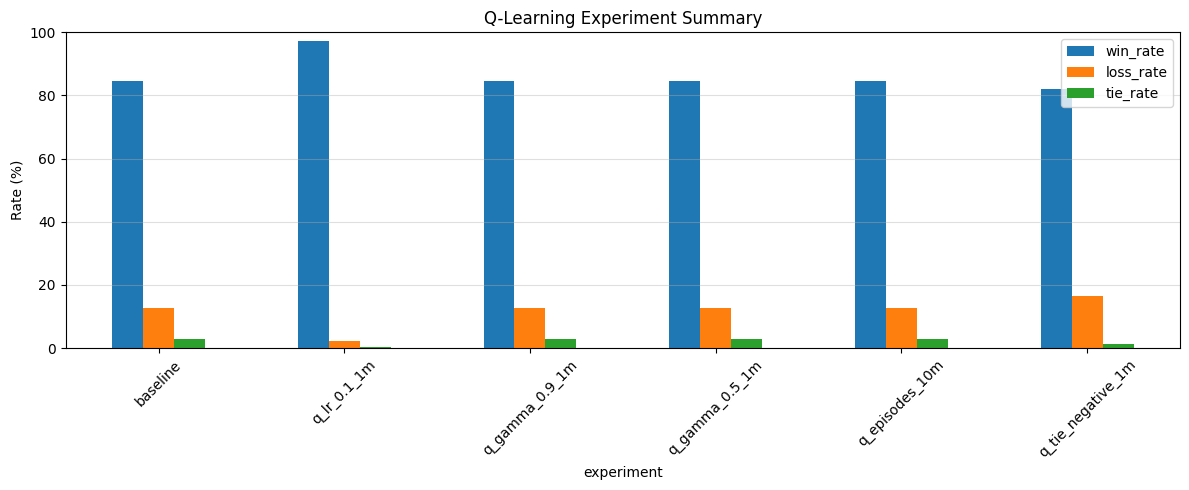

Summary saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/q_learning_experiment_summary.csv


In [ ]:
def changed_config_keys(config, baseline_config):
    return {
        key
        for key in baseline_config
        if config[key] != baseline_config[key]
    }


assert changed_config_keys(
    lr_config,
    Q_BASELINE_CONFIG
) == {"learning_rate"}

assert changed_config_keys(
    gamma_09_config,
    Q_BASELINE_CONFIG
) == {"discount_factor"}

assert changed_config_keys(
    gamma_05_config,
    Q_BASELINE_CONFIG
) == {"discount_factor"}

assert changed_config_keys(
    ep_10m_config,
    Q_BASELINE_CONFIG
) == {"episodes"}

assert changed_config_keys(
    neg_tie_config,
    Q_BASELINE_CONFIG
) == {"tie_reward"}


q_summary_list = [
    baseline_q_results,
    eval_lr_01,
    eval_g09,
    eval_g05,
    eval_10m,
    eval_neg
]
final_summary_df = pd.DataFrame(q_summary_list)

assert final_summary_df["experiment"].is_unique
assert (final_summary_df["evaluation_games"] == 1000).all()
assert (final_summary_df["states"] > 0).all()

summary_columns = [
    "experiment",
    "states",
    "win_rate",
    "loss_rate",
    "tie_rate"
]
display(final_summary_df[summary_columns])

summary_file = (
    Q_RESULTS_PATH / "q_learning_experiment_summary.csv"
)
final_summary_df.to_csv(summary_file, index=False)

final_summary_df.plot(
    x="experiment",
    y=["win_rate", "loss_rate", "tie_rate"],
    kind="bar",
    figsize=(12, 5)
)
plt.title("Q-Learning Experiment Summary")
plt.ylabel("Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Summary saved: {summary_file}")

### Overall Q-Learning Conclusion

The corrected baseline achieved **84.5% wins**, **12.7% losses** and **2.8% ties**.

Increasing the learning rate to `0.1` produced the strongest evaluated result: **97.4% wins**, **2.2% losses** and **0.4% ties**.

Lower discount factors produced unchanged aggregate evaluation rates, despite changing the Bellman targets. Ten times more training increased state coverage without improving those rates. Neither result proves that the underlying policies were identical.

A negative tie reward reduced draws but increased losses. This is consistent with the reward ordering, which assigned a higher reward to losing than to drawing.

These findings apply to the tested configurations and fixed seeds, with agent X playing first against random O. They do not establish optimal play or universal hyperparameter choices.

#### Game Play

The trained Q-learning agent plays as X against random O. The agent uses a greedy policy and selects only legal actions.

In [ ]:
def play_q_learning_games(
    q_table_to_use,
    number_of_games=100,
    seed=2026,
    print_games=True
):
    """Play greedy Q-learning agent X against random O."""
    rng = random.Random(seed)
    total_wins = total_losses = total_ties = 0

    for game_number in range(1, number_of_games + 1):
        local_game = TicTacToe(BOARD_SIZE)
        letter = "X"

        if print_games:
            print(f"Game: {game_number}")

        while local_game.empty_squares():
            moves = local_game.available_moves()

            if letter == "X":
                square = select_greedy_q_action(
                    q_table_to_use,
                    local_game.board,
                    moves,
                    rng
                )
                player_name = "Q-learning Agent (X)"
            else:
                square = rng.choice(moves)
                player_name = "Random Opponent (O)"

            if print_games:
                print(f"{player_name}: {square}")

            local_game.make_move(square, letter)

            if print_games:
                local_game.print_board()
                print("_" * 50)

            if local_game.current_winner:
                if letter == "X":
                    total_wins += 1
                    result = "Winner is the Q-learning Agent."
                else:
                    total_losses += 1
                    result = "Winner is the Random Opponent."

                if print_games:
                    print(f"{result}\n")
                break

            if not local_game.empty_squares():
                total_ties += 1

                if print_games:
                    print("It's a Tie.\n")
                break

            letter = "O" if letter == "X" else "X"

    return total_wins, total_losses, total_ties


total_wins, total_losses, total_ties = play_q_learning_games(
    q_table,
    number_of_games=100,
    seed=2026,
    print_games=True
)

print("\nGame Play Summary")
print(f"Wins:   {total_wins}")
print(f"Losses: {total_losses}")
print(f"Ties:   {total_ties}")

assert total_wins + total_losses + total_ties == 100

Game: 1
Q-learning Agent (X): 1
|   | X |   |
|   |   |   |
|   |   |   |
__________________________________________________
Random Opponent (O): 2
|   | X | O |
|   |   |   |
|   |   |   |
__________________________________________________
Q-learning Agent (X): 7
|   | X | O |
|   |   |   |
|   | X |   |
__________________________________________________
Random Opponent (O): 4
|   | X | O |
|   | O |   |
|   | X |   |
__________________________________________________
Q-learning Agent (X): 8
|   | X | O |
|   | O |   |
|   | X | X |
__________________________________________________
Random Opponent (O): 0
| O | X | O |
|   | O |   |
|   | X | X |
__________________________________________________
Q-learning Agent (X): 3
| O | X | O |
| X | O |   |
|   | X | X |
__________________________________________________
Random Opponent (O): 5
| O | X | O |
| X | O | O |
|   | X | X |
__________________________________________________
Q-learning Agent (X): 6
| O | X | O |
| X | O | O |
| X | X 

#### Played Game Stats

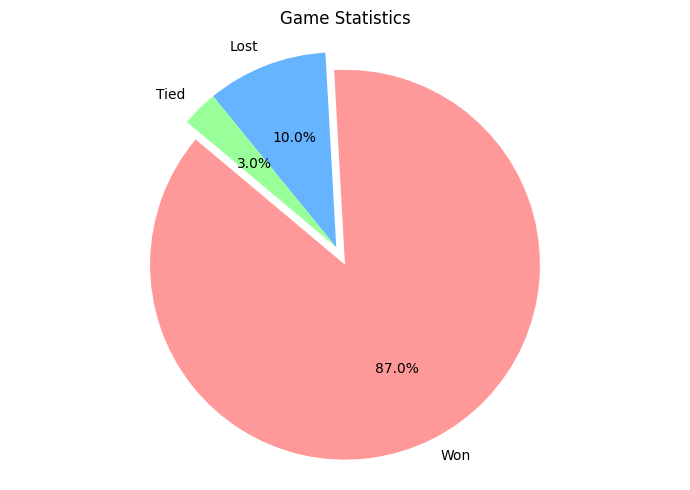

Game statistics saved: /content/drive/MyDrive/Projects/Project 4/results/q_learning/game_stats_q_learning.jpg


In [ ]:
labels = ["Won", "Lost", "Tied"]
sizes = [total_wins, total_losses, total_ties]
colors = ["#ff9999", "#66b3ff", "#99ff99"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(
    sizes,
    explode=(0.1, 0, 0),
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140
)
ax.axis("equal")
ax.set_title("Game Statistics")

game_stats_file = (
    Q_RESULTS_PATH / "game_stats_q_learning.jpg"
)
plt.tight_layout()
plt.savefig(game_stats_file, bbox_inches="tight")
plt.show()

print(f"Game statistics saved: {game_stats_file}")

# 3. DQN & DDQN
## DQN (Deep Q-Network):
* In DQN, a target network is employed to determine the best action for the next state from the current state during the game. This separate model, the target network, mirrors the architecture of the main network but with periodically updated weights.
* Once the best action is selected by the target network, its Q-value is estimated using the same target network, not the main network. This approach aims to stabilize training by reducing the frequency of policy changes, as the target network's weights are updated less often than those of the main network.
* However, using the same network to both select and evaluate an action can sometimes lead to overestimations of Q-values. This is due to positive biases inherent in the bootstrapping methods where the maximum estimated returns are used for updates. In a game context, such overestimations can lead the learning process to favor certain strategies that might not be as effective as predicted, potentially affecting overall strategy development in gameplay.

## DDQN (Double Deep Q-Network):

* DDQN modifies the DQN approach by splitting the role of action selection and Q-value estimation between two networks. In this setup, the main network is used to choose the best action from the next state.
* However, unlike DQN, the Q-value of this action is evaluated using the target network. This cross-evaluation helps in mitigating the overestimation issue seen in DQN.
* By decoupling the selection and evaluation of actions, DDQN provides a more conservative estimate of Q-values, is designed to reduce overestimation and may improve training stability. In the context of Tic Tac Toe, this means DDQN can more reliably evaluate the potential future benefits of moves, leading to more strategic decision-making and potentially stronger gameplay over time.

## 3.a - Integrating a Neural Network into Q-Learning

DQN replaces the Q-table with a neural network $Q_\theta(s,a)$. The input is the nine-cell board (`0` = empty, `1` = X, `-1` = O); the output is nine action values, not probabilities. The online network selects the highest-valued legal action, with epsilon-greedy exploration during training.

The network learns from Bellman targets:

$$
y = \begin{cases}
r, & \text{terminal transition},\\
r + \gamma \max_{a'\in A_{\mathrm{legal}}(s')}Q_{\theta^-}(s',a'), & \text{otherwise}.
\end{cases}
$$

The online network is updated toward these targets. A separate target network starts with the same weights and is synchronized periodically to make the targets less rapidly changing. In the introductory description above, target-network action selection refers to this Bellman calculation; actual gameplay uses the online network.

Replay memory stores X's decisions, including O's response, and supplies random minibatches. This reuses experience and reduces correlations between consecutive updates. Terminal transitions do not bootstrap, and occupied squares are excluded from action selection and future-value maximization.

**Advantages:** parameter sharing can generalize across states and supports larger state spaces than an explicit table.

**Disadvantages:** neural approximation introduces computational cost, hyperparameter sensitivity, possible instability and overestimation. For small Tic-Tac-Toe boards, tabular Q-learning remains a practical alternative; a neural network is not inherently better.

## 3.b - Proposed DQN Architecture

The `_build_model` method implements the following fully connected network:

| Layer | Units | Activation |
|---|---:|---|
| Input | 9 board values | — |
| Dense | 64 | ReLU |
| Dense | 64 | ReLU |
| Dense | 32 | ReLU |
| Dense output | 9 action values | Linear |

The network has **7,177 trainable parameters**. Hidden layers can represent nonlinear board patterns; linear outputs allow both positive and negative Q-values. No dropout is used, avoiding additional stochasticity in already changing learning targets.

Both algorithms use Adam with a configurable learning rate and Huber loss, which is less sensitive to large errors than squared loss. DQN and DDQN share this architecture; only their non-terminal target calculation differs. The next cell checks output shape, initial target synchronization and legal action selection; trained performance is evaluated below.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber


class DQNAgent:
    def __init__(
        self,
        state_size,
        action_size,
        algorithm="DQN",
        learning_rate=0.001,
        gamma=0.95,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.01,
        batch_size=32,
        memory_size=50000,
        target_update_interval=10,
        seed=42
    ):
        algorithm = algorithm.upper()

        if algorithm not in {"DQN", "DDQN"}:
            raise ValueError(
                "algorithm must be either 'DQN' or 'DDQN'"
            )

        self.state_size = state_size
        self.action_size = action_size
        self.algorithm = algorithm
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size
        self.memory_size = memory_size
        self.target_update_interval = target_update_interval
        self.seed = seed

        self.python_rng = random.Random(seed)
        self.numpy_rng = np.random.default_rng(seed)
        self.replay_memory = deque(maxlen=memory_size)

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(64, activation="relu"),
            Dense(64, activation="relu"),
            Dense(32, activation="relu"),
            Dense(self.action_size, activation="linear")
        ])

        model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss=Huber()
        )
        return model

    def act(self, state, legal_actions, training=True):
        """Select an epsilon-greedy legal action."""
        if not legal_actions:
            raise ValueError(
                "legal_actions must not be empty"
            )

        legal_actions = list(legal_actions)

        if (
            training
            and self.numpy_rng.random() < self.epsilon
        ):
            return self.python_rng.choice(legal_actions)

        q_values = self.predict_q_values(state)
        return max(
            legal_actions,
            key=lambda action: q_values[action]
        )

    def remember(
        self,
        state,
        action,
        reward,
        next_state,
        done,
        next_legal_actions
    ):
        """Store one transition generated by agent X."""
        state = np.asarray(
            state,
            dtype=np.float32
        ).reshape(self.state_size)

        if done:
            stored_next_state = np.zeros(
                self.state_size,
                dtype=np.float32
            )
            stored_next_actions = tuple()
        else:
            if next_state is None:
                raise ValueError(
                    "A non-terminal transition requires "
                    "next_state."
                )

            stored_next_state = np.asarray(
                next_state,
                dtype=np.float32
            ).reshape(self.state_size)
            stored_next_actions = tuple(
                next_legal_actions
            )

            if not stored_next_actions:
                raise ValueError(
                    "A non-terminal transition requires "
                    "at least one legal next action."
                )

        self.replay_memory.append((
            state,
            int(action),
            float(reward),
            stored_next_state,
            bool(done),
            stored_next_actions
        ))

    def replay(self):
        """Train the online network on one random minibatch."""
        if len(self.replay_memory) < self.batch_size:
            return None

        minibatch = self.python_rng.sample(
            self.replay_memory,
            self.batch_size
        )

        states = np.asarray(
            [transition[0] for transition in minibatch],
            dtype=np.float32
        )
        next_states = np.asarray(
            [transition[3] for transition in minibatch],
            dtype=np.float32
        )

        target_vectors = self.model.predict(
            states,
            verbose=0
        )

        non_terminal_indices = [
            index
            for index, transition in enumerate(minibatch)
            if not transition[4]
        ]

        target_next_q = None
        online_next_q = None

        if non_terminal_indices:
            relevant_next_states = next_states[
                non_terminal_indices
            ]
            target_next_q = self.target_model.predict(
                relevant_next_states,
                verbose=0
            )

            if self.algorithm == "DDQN":
                online_next_q = self.model.predict(
                    relevant_next_states,
                    verbose=0
                )

        prediction_positions = {
            minibatch_index: prediction_index
            for prediction_index, minibatch_index
            in enumerate(non_terminal_indices)
        }

        for index, transition in enumerate(minibatch):
            (
                _,
                action,
                reward,
                _,
                done,
                next_legal_actions
            ) = transition

            if done:
                bellman_target = reward
            else:
                prediction_index = prediction_positions[index]
                legal_actions = list(next_legal_actions)

                if self.algorithm == "DQN":
                    best_future_value = max(
                        target_next_q[
                            prediction_index,
                            legal_actions
                        ]
                    )
                else:
                    best_next_action = max(
                        legal_actions,
                        key=lambda legal_action:
                            online_next_q[
                                prediction_index,
                                legal_action
                            ]
                    )
                    best_future_value = target_next_q[
                        prediction_index,
                        best_next_action
                    ]

                bellman_target = (
                    reward
                    + self.gamma * best_future_value
                )

            target_vectors[index, action] = bellman_target

        loss = self.model.train_on_batch(
            states,
            target_vectors
        )
        return float(np.asarray(loss).reshape(-1)[0])

    def end_episode(self, episode_number):
        """Decay epsilon and periodically update the target."""
        self.epsilon = max(
            self.epsilon_min,
            self.epsilon * self.epsilon_decay
        )

        if (
            episode_number > 0
            and episode_number
            % self.target_update_interval == 0
        ):
            self.update_target_model()

    def update_target_model(self):
        self.target_model.set_weights(
            self.model.get_weights()
        )

    def predict_q_values(self, state):
        state = np.asarray(
            state,
            dtype=np.float32
        ).reshape(1, self.state_size)

        return self.model.predict(
            state,
            verbose=0
        )[0]

In [14]:
tf.keras.utils.set_random_seed(SEED)

architecture_check_agent = DQNAgent(
    state_size=ACTION_SIZE,
    action_size=ACTION_SIZE,
    algorithm="DQN",
    learning_rate=0.001,
    seed=SEED
)

empty_state = np.zeros(
    ACTION_SIZE,
    dtype=np.float32
)
q_values = architecture_check_agent.predict_q_values(
    empty_state
)
assert q_values.shape == (ACTION_SIZE,)

for online_weights, target_weights in zip(
    architecture_check_agent.model.get_weights(),
    architecture_check_agent.target_model.get_weights()
):
    assert np.allclose(
        online_weights,
        target_weights
    )

test_state = np.array(
    [0, 1, 0, 1, -1, 0, -1, -1, 1],
    dtype=np.float32
)
legal_actions = np.where(
    test_state == 0
)[0].tolist()

selected_action = architecture_check_agent.act(
    test_state,
    legal_actions,
    training=False
)
assert selected_action in legal_actions

print("Architecture and legal-action checks passed.")
architecture_check_agent.model.summary()

Architecture and legal-action checks passed.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,177 (28.04 KB)

 Trainable params: 7,177 (28.04 KB)

 Non-trainable params: 0 (0.00 B)

## 3.b–c - Controlled DQN and DDQN Experiment

DQN uses the target network both to select and evaluate the next action. DDQN separates these roles:

$$
a^* = \arg\max_{a'\in A_{\mathrm{legal}}(s')}Q_{\mathrm{online}}(s',a'),
\qquad y_{\mathrm{DDQN}} = r + \gamma Q_{\mathrm{target}}(s',a^*).
$$

Taking a maximum over noisy estimates can favor positive estimation errors. DDQN is designed to reduce this effect, but improvement is not guaranteed. For both algorithms, terminal targets are simply $y=r$.

Each replay transition starts before X's move and ends after O's response, unless X already ends the game. Thus a loss caused by O's response updates X's preceding decision, not O's action. One replay update is attempted per X decision once the memory contains a full minibatch.

| Shared parameter | Value |
|---|---:|
| Training episodes | 1000 |
| Baseline Adam learning rate | 0.01 |
| Discount factor | 0.95 |
| Initial / minimum epsilon | 1.0 / 0.01 |
| Epsilon multiplier | 0.995 per episode |
| Batch size / replay capacity | 32 / 50000 |
| Target synchronization | Every 10 episodes |
| Training seed | 42 |
| Win / loss / tie / step reward | 1.0 / -10.0 / 0.5 / 0.002 |

Within each learning-rate setting, DQN and DDQN use the same configuration and seed. All agents play as X against random O. Evaluation compares win, loss and tie rates; the bonus also examines within-run training variation and an empirical value-estimation diagnostic.

In [15]:
import time


DEEP_BASE_CONFIG = {
    "state_size": ACTION_SIZE,
    "action_size": ACTION_SIZE,
    "learning_rate": 0.01,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_decay": 0.995,
    "epsilon_min": 0.01,
    "batch_size": 32,
    "memory_size": 50000,
    "target_update_interval": 10,
    "episodes": 1000,
    "history_interval": 50,
    "rewards": {
        "win": 1.0,
        "loss": -10.0,
        "tie": 0.5,
        "step": 0.002
    }
}


def encode_board(board):
    """Encode empty, X and O as 0, 1 and -1."""
    values = {
        " ": 0.0,
        "X": 1.0,
        "O": -1.0
    }
    encoded = np.asarray(
        [values[cell] for cell in board],
        dtype=np.float32
    )

    assert encoded.shape == (ACTION_SIZE,)
    return encoded


def create_deep_agent(algorithm, config, seed):
    return DQNAgent(
        state_size=config["state_size"],
        action_size=config["action_size"],
        algorithm=algorithm,
        learning_rate=config["learning_rate"],
        gamma=config["gamma"],
        epsilon=config["epsilon"],
        epsilon_decay=config["epsilon_decay"],
        epsilon_min=config["epsilon_min"],
        batch_size=config["batch_size"],
        memory_size=config["memory_size"],
        target_update_interval=config[
            "target_update_interval"
        ],
        seed=seed
    )


def train_deep_agent(
    algorithm,
    config,
    seed=SEED,
    episodes=None,
    history_interval=None,
    show_progress=True
):
    """Train DQN or DDQN as X against random O."""
    algorithm = algorithm.upper()

    if algorithm not in {"DQN", "DDQN"}:
        raise ValueError(
            "algorithm must be 'DQN' or 'DDQN'."
        )

    episodes = (
        config["episodes"]
        if episodes is None
        else episodes
    )
    history_interval = (
        config["history_interval"]
        if history_interval is None
        else history_interval
    )

    if episodes <= 0 or history_interval <= 0:
        raise ValueError(
            "episodes and history_interval must be positive."
        )

    tf.keras.utils.set_random_seed(seed)
    opponent_rng = random.Random(seed + 10000)
    agent = create_deep_agent(
        algorithm,
        config,
        seed
    )
    rewards = config["rewards"]

    cumulative_results = {
        "win": 0,
        "loss": 0,
        "tie": 0
    }
    window_results = {
        "win": 0,
        "loss": 0,
        "tie": 0
    }

    cumulative_agent_actions = 0
    cumulative_opponent_actions = 0
    window_agent_actions = 0
    window_opponent_actions = 0
    window_replay_losses = []
    history = []

    start_time = time.perf_counter()
    episode_iterator = tqdm(
        range(1, episodes + 1),
        disable=not show_progress
    )

    for episode_number in episode_iterator:
        local_game = TicTacToe(BOARD_SIZE)

        while True:
            state = encode_board(
                local_game.board
            )
            legal_x_actions = (
                local_game.available_moves()
            )

            if not legal_x_actions:
                raise RuntimeError(
                    "X received a state with no legal actions."
                )

            x_action = agent.act(
                state,
                legal_x_actions,
                training=True
            )
            assert x_action in legal_x_actions

            local_game.make_move(x_action, "X")
            cumulative_agent_actions += 1
            window_agent_actions += 1

            next_state = None
            next_legal_actions = []
            done = True

            if local_game.current_winner == "X":
                reward = rewards["win"]
                episode_result = "win"

            elif not local_game.empty_squares():
                reward = rewards["tie"]
                episode_result = "tie"

            else:
                o_action = opponent_rng.choice(
                    local_game.available_moves()
                )
                local_game.make_move(o_action, "O")
                cumulative_opponent_actions += 1
                window_opponent_actions += 1

                if local_game.current_winner == "O":
                    reward = rewards["loss"]
                    episode_result = "loss"

                elif not local_game.empty_squares():
                    reward = rewards["tie"]
                    episode_result = "tie"

                else:
                    reward = rewards["step"]
                    episode_result = None
                    done = False
                    next_state = encode_board(
                        local_game.board
                    )
                    next_legal_actions = (
                        local_game.available_moves()
                    )

            agent.remember(
                state,
                x_action,
                reward,
                next_state,
                done,
                next_legal_actions
            )

            replay_loss = agent.replay()

            if replay_loss is not None:
                if not np.isfinite(replay_loss):
                    raise FloatingPointError(
                        "Replay produced a non-finite loss."
                    )
                window_replay_losses.append(
                    replay_loss
                )

            if done:
                break

        cumulative_results[episode_result] += 1
        window_results[episode_result] += 1
        agent.end_episode(episode_number)

        should_record = (
            episode_number % history_interval == 0
            or episode_number == episodes
        )

        if should_record:
            window_games = sum(
                window_results.values()
            )
            cumulative_games = sum(
                cumulative_results.values()
            )
            mean_replay_loss = (
                float(np.mean(window_replay_losses))
                if window_replay_losses
                else np.nan
            )

            history.append({
                "algorithm": algorithm,
                "seed": seed,
                "episode": episode_number,
                "epsilon": agent.epsilon,
                "replay_memory_size": len(
                    agent.replay_memory
                ),
                "window_games": window_games,
                "window_win_rate": (
                    100
                    * window_results["win"]
                    / window_games
                ),
                "window_loss_rate": (
                    100
                    * window_results["loss"]
                    / window_games
                ),
                "window_tie_rate": (
                    100
                    * window_results["tie"]
                    / window_games
                ),
                "cumulative_win_rate": (
                    100
                    * cumulative_results["win"]
                    / cumulative_games
                ),
                "cumulative_loss_rate": (
                    100
                    * cumulative_results["loss"]
                    / cumulative_games
                ),
                "cumulative_tie_rate": (
                    100
                    * cumulative_results["tie"]
                    / cumulative_games
                ),
                "mean_replay_loss": mean_replay_loss,
                "window_agent_actions": (
                    window_agent_actions
                ),
                "window_opponent_actions": (
                    window_opponent_actions
                )
            })

            window_results = {
                "win": 0,
                "loss": 0,
                "tie": 0
            }
            window_agent_actions = 0
            window_opponent_actions = 0
            window_replay_losses = []

    training_seconds = (
        time.perf_counter() - start_time
    )

    assert sum(cumulative_results.values()) == episodes

    summary = {
        "algorithm": algorithm,
        "seed": seed,
        "episodes": episodes,
        "training_seconds": training_seconds,
        "wins": cumulative_results["win"],
        "losses": cumulative_results["loss"],
        "ties": cumulative_results["tie"],
        "win_rate": (
            100 * cumulative_results["win"] / episodes
        ),
        "loss_rate": (
            100 * cumulative_results["loss"] / episodes
        ),
        "tie_rate": (
            100 * cumulative_results["tie"] / episodes
        ),
        "final_epsilon": agent.epsilon,
        "replay_memory_size": len(
            agent.replay_memory
        ),
        "agent_actions": cumulative_agent_actions,
        "opponent_actions": cumulative_opponent_actions
    }

    return agent, pd.DataFrame(history), summary

### Training and Saved Artifacts

Each run saves its online model, history, summary and configuration. `Run all` loads the run when all four files exist and `FORCE_TRAIN=False`; otherwise it trains from scratch. Loading is for evaluation, not exact training resumption: replay memory and all training state are not restored.

The loader checks file existence, not configuration equality. New configurations therefore need distinct experiment paths, as used for the LR experiment below.

In [16]:
import json


DQN_RESULTS_PATH = RESULTS_PATH / "dqn"
DDQN_RESULTS_PATH = RESULTS_PATH / "ddqn"

for path in [DQN_RESULTS_PATH, DDQN_RESULTS_PATH]:
    path.mkdir(parents=True, exist_ok=True)


config_1000 = {
    **DEEP_BASE_CONFIG,
    "episodes": 1000,
    "history_interval": 50
}


def save_deep_run(
    agent,
    history_df,
    summary,
    config,
    model_path,
    history_path,
    summary_path,
    config_path
):
    """Save a trained deep-learning experiment."""
    agent.model.save(model_path)
    history_df.to_csv(history_path, index=False)

    with open(
        summary_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(summary, file, indent=4)

    with open(
        config_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(config, file, indent=4)

    print(f"{agent.algorithm} artifacts saved.")


def load_deep_run(
    algorithm,
    config,
    model_path,
    history_path,
    summary_path
):
    """Load a trained deep-learning experiment."""
    agent = create_deep_agent(
        algorithm,
        config,
        SEED
    )
    agent.model = tf.keras.models.load_model(
        model_path
    )
    agent.update_target_model()

    history_df = pd.read_csv(history_path)

    with open(
        summary_path,
        "r",
        encoding="utf-8"
    ) as file:
        summary = json.load(file)

    agent.epsilon = float(
        summary["final_epsilon"]
    )

    print(f"{algorithm} artifacts loaded.")
    return agent, history_df, summary


def train_save_or_load_deep_run(
    algorithm,
    config,
    model_path,
    history_path,
    summary_path,
    config_path
):
    """Load existing artifacts or train and save a new run."""
    required_files = [
        model_path,
        history_path,
        summary_path,
        config_path
    ]

    artifacts_exist = all(
        Path(path).exists()
        for path in required_files
    )

    if artifacts_exist and not FORCE_TRAIN:
        return load_deep_run(
            algorithm,
            config,
            model_path,
            history_path,
            summary_path
        )

    print(f"Training {algorithm} from scratch...")

    agent, history_df, summary = train_deep_agent(
        algorithm,
        config,
        seed=SEED,
        show_progress=True
    )

    save_deep_run(
        agent,
        history_df,
        summary,
        config,
        model_path,
        history_path,
        summary_path,
        config_path
    )

    return agent, history_df, summary


DQN_1000_MODEL_FILE = (
    DQN_MODELS_PATH / "dqn_1000.keras"
)
DQN_1000_HISTORY_FILE = (
    DQN_RESULTS_PATH / "dqn_1000_history.csv"
)
DQN_1000_SUMMARY_FILE = (
    DQN_RESULTS_PATH / "dqn_1000_summary.json"
)
DQN_1000_CONFIG_FILE = (
    DQN_RESULTS_PATH / "dqn_1000_config.json"
)

DDQN_1000_MODEL_FILE = (
    DDQN_MODELS_PATH / "ddqn_1000.keras"
)
DDQN_1000_HISTORY_FILE = (
    DDQN_RESULTS_PATH / "ddqn_1000_history.csv"
)
DDQN_1000_SUMMARY_FILE = (
    DDQN_RESULTS_PATH / "ddqn_1000_summary.json"
)
DDQN_1000_CONFIG_FILE = (
    DDQN_RESULTS_PATH / "ddqn_1000_config.json"
)


dqn_agent, dqn_history, dqn_summary = (
    train_save_or_load_deep_run(
        "DQN",
        config_1000,
        DQN_1000_MODEL_FILE,
        DQN_1000_HISTORY_FILE,
        DQN_1000_SUMMARY_FILE,
        DQN_1000_CONFIG_FILE
    )
)

ddqn_agent, ddqn_history, ddqn_summary = (
    train_save_or_load_deep_run(
        "DDQN",
        config_1000,
        DDQN_1000_MODEL_FILE,
        DDQN_1000_HISTORY_FILE,
        DDQN_1000_SUMMARY_FILE,
        DDQN_1000_CONFIG_FILE
    )
)

print("\nDQN and DDQN runs are ready.")

DQN artifacts loaded.
DDQN artifacts loaded.

DQN and DDQN runs are ready.


In [17]:
training_1000_summary_df = pd.DataFrame([
    dqn_summary,
    ddqn_summary
])

training_1000_history_df = pd.concat(
    [dqn_history, ddqn_history],
    ignore_index=True
)

training_summary_columns = [
    "algorithm",
    "episodes",
    "training_seconds",
    "win_rate",
    "loss_rate",
    "tie_rate",
    "final_epsilon"
]

print("Baseline training summary:")
display(
    training_1000_summary_df[
        training_summary_columns
    ]
)

Baseline training summary:


,algorithm,episodes,training_seconds,win_rate,loss_rate,tie_rate,final_epsilon
0,DQN,1000,847.231427,68.3,20.1,11.6,0.01
1,DDQN,1000,1153.516188,70.5,18.3,11.2,0.01


### Greedy Baseline Evaluation

Training rates include exploration. Here each frozen model plays 5000 evaluation games with exploration disabled, using evaluation seed 2026 and a separate random-opponent generator for each game. Seeds and rules match across agents, but actual move sequences can differ because their policies produce different boards. No weights are updated.

In [18]:
def evaluate_deep_agent_batched(
    agent,
    num_games=5000,
    seed=2026
):
    """Evaluate a deep agent greedily against random O."""
    games = [
        TicTacToe(BOARD_SIZE)
        for _ in range(num_games)
    ]
    opponent_rngs = [
        random.Random(seed + game_index)
        for game_index in range(num_games)
    ]
    active_games = list(range(num_games))

    results = {
        "wins": 0,
        "losses": 0,
        "ties": 0
    }
    agent_actions = 0
    opponent_actions = 0

    while active_games:
        states = np.asarray(
            [
                encode_board(games[index].board)
                for index in active_games
            ],
            dtype=np.float32
        )
        q_value_batches = agent.model.predict(
            states,
            verbose=0
        )
        next_active_games = []

        for position, game_index in enumerate(
            active_games
        ):
            local_game = games[game_index]
            legal_actions = (
                local_game.available_moves()
            )

            if not legal_actions:
                raise RuntimeError(
                    "X received a state with no legal actions."
                )

            q_values = q_value_batches[position]
            x_action = max(
                legal_actions,
                key=lambda action: q_values[action]
            )
            local_game.make_move(x_action, "X")
            agent_actions += 1

            if local_game.current_winner == "X":
                results["wins"] += 1
                continue

            if not local_game.empty_squares():
                results["ties"] += 1
                continue

            o_action = opponent_rngs[
                game_index
            ].choice(
                local_game.available_moves()
            )
            local_game.make_move(o_action, "O")
            opponent_actions += 1

            if local_game.current_winner == "O":
                results["losses"] += 1
                continue

            if not local_game.empty_squares():
                results["ties"] += 1
                continue

            next_active_games.append(game_index)

        active_games = next_active_games

    assert sum(results.values()) == num_games

    return {
        "algorithm": agent.algorithm,
        "evaluation_games": num_games,
        "evaluation_seed": seed,
        "wins": results["wins"],
        "losses": results["losses"],
        "ties": results["ties"],
        "win_rate": (
            100 * results["wins"] / num_games
        ),
        "loss_rate": (
            100 * results["losses"] / num_games
        ),
        "tie_rate": (
            100 * results["ties"] / num_games
        ),
        "agent_actions": agent_actions,
        "opponent_actions": opponent_actions,
        "average_agent_actions": (
            agent_actions / num_games
        ),
        "exploration": False
    }


DEEP_EVALUATION_GAMES = 5000
DEEP_EVALUATION_SEED = 2026

dqn_evaluation = evaluate_deep_agent_batched(
    dqn_agent,
    DEEP_EVALUATION_GAMES,
    DEEP_EVALUATION_SEED
)
ddqn_evaluation = evaluate_deep_agent_batched(
    ddqn_agent,
    DEEP_EVALUATION_GAMES,
    DEEP_EVALUATION_SEED
)

deep_baseline_evaluation_df = pd.DataFrame([
    dqn_evaluation,
    ddqn_evaluation
])

DEEP_COMPARISON_RESULTS_PATH = (
    RESULTS_PATH / "deep_comparison"
)
DEEP_COMPARISON_RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

DEEP_BASELINE_EVALUATION_FILE = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_baseline_evaluation.csv"
)
deep_baseline_evaluation_df.to_csv(
    DEEP_BASELINE_EVALUATION_FILE,
    index=False
)

evaluation_columns = [
    "algorithm",
    "evaluation_games",
    "wins",
    "losses",
    "ties",
    "win_rate",
    "loss_rate",
    "tie_rate"
]

print("Greedy DQN/DDQN baseline evaluation:")
display(
    deep_baseline_evaluation_df[
        evaluation_columns
    ]
)
print(
    f"Evaluation saved: "
    f"{DEEP_BASELINE_EVALUATION_FILE}"
)

Greedy DQN/DDQN baseline evaluation:


,algorithm,evaluation_games,wins,losses,ties,win_rate,loss_rate,tie_rate
0,DQN,5000,3396,1150,454,67.92,23.00,9.08
1,DDQN,5000,3268,1013,719,65.36,20.26,14.38


Evaluation saved: /content/drive/MyDrive/Projects/Project 4/results/deep_comparison/deep_baseline_evaluation.csv


### Empirical Value-Estimation Diagnostic

For each of 2423 legal non-terminal X-turn states, compare the predicted value of the greedy action with the mean discounted return from 50 rollouts following that model's greedy policy against random O (seed 3030):

$$
\mathrm{Gap}(s)=Q_\theta(s,a_{\mathrm{greedy}})-\widehat{V}^{\pi}(s).
$$

A positive gap means the prediction exceeds the sampled policy return. This is not a direct measurement of maximization bias or error relative to the optimal value: it also reflects policy quality, approximation error and rollout noise. States receive equal weight, unlike their visitation frequencies in games starting from an empty board. Mean gap, median gap, positive-gap frequency and absolute gap describe different aspects of this diagnostic.

Legal non-terminal X-turn states: 2423


DDQN diagnostic: 100%|██████████| 2423/2423 [00:01<00:00, 1228.99it/s]


Empirical overestimation summary:


,algorithm,evaluated_states,mean_predicted_q,mean_empirical_return,mean_overestimation_gap,median_overestimation_gap,positive_gap_rate,mean_absolute_gap
0,DDQN,2423,0.6939,-0.8275,1.5214,0.0445,53.5287,1.8377
1,DQN,2423,0.7993,-0.7754,1.5747,0.1206,60.4622,1.7634


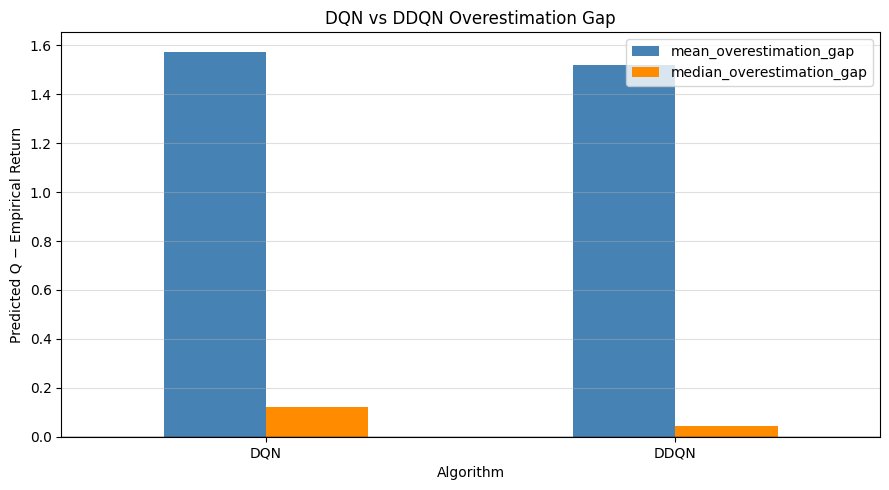

Overestimation summary saved: /content/drive/MyDrive/Projects/Project 4/results/deep_comparison/deep_overestimation_summary.csv


In [19]:
from itertools import product


WINNING_LINES = [
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8),
    (0, 3, 6),
    (1, 4, 7),
    (2, 5, 8),
    (0, 4, 8),
    (2, 4, 6)
]


def board_has_winner(board, player):
    return any(
        all(board[position] == player for position in line)
        for line in WINNING_LINES
    )


def generate_legal_x_turn_states():
    """Generate non-terminal states in which X plays next."""
    states = []

    for state in product(
        [-1.0, 0.0, 1.0],
        repeat=ACTION_SIZE
    ):
        if state.count(1.0) != state.count(-1.0):
            continue

        if 0.0 not in state:
            continue

        if (
            board_has_winner(state, 1.0)
            or board_has_winner(state, -1.0)
        ):
            continue

        states.append(state)

    return states


def build_greedy_policy(agent, states):
    """Map each state to its greedy action and Q-value."""
    state_array = np.asarray(
        states,
        dtype=np.float32
    )
    q_value_batches = agent.model.predict(
        state_array,
        verbose=0
    )

    policy = {}
    predicted_values = {}

    for state, q_values in zip(
        states,
        q_value_batches
    ):
        legal_actions = [
            action
            for action, value in enumerate(state)
            if value == 0.0
        ]
        greedy_action = max(
            legal_actions,
            key=lambda action: q_values[action]
        )

        policy[state] = greedy_action
        predicted_values[state] = float(
            q_values[greedy_action]
        )

    return policy, predicted_values


def simulate_discounted_return(
    initial_state,
    policy,
    rewards,
    gamma,
    opponent_rng
):
    """Run one greedy rollout against random O."""
    board = list(initial_state)
    discounted_return = 0.0
    discount = 1.0

    while True:
        state = tuple(board)
        x_action = policy[state]
        board[x_action] = 1.0

        if board_has_winner(board, 1.0):
            return (
                discounted_return
                + discount * rewards["win"]
            )

        if 0.0 not in board:
            return (
                discounted_return
                + discount * rewards["tie"]
            )

        legal_o_actions = [
            action
            for action, value in enumerate(board)
            if value == 0.0
        ]
        o_action = opponent_rng.choice(
            legal_o_actions
        )
        board[o_action] = -1.0

        if board_has_winner(board, -1.0):
            return (
                discounted_return
                + discount * rewards["loss"]
            )

        if 0.0 not in board:
            return (
                discounted_return
                + discount * rewards["tie"]
            )

        discounted_return += (
            discount * rewards["step"]
        )
        discount *= gamma


def estimate_overestimation(
    agent,
    states,
    rewards,
    gamma,
    rollouts_per_state=50,
    seed=3030
):
    """Compare predicted Q-values with empirical returns."""
    policy, predicted_values = build_greedy_policy(
        agent,
        states
    )
    rows = []

    state_iterator = tqdm(
        enumerate(states),
        total=len(states),
        desc=f"{agent.algorithm} diagnostic"
    )

    for state_index, state in state_iterator:
        rollout_returns = []

        for rollout_index in range(
            rollouts_per_state
        ):
            rollout_seed = (
                seed
                + state_index * rollouts_per_state
                + rollout_index
            )
            rollout_return = simulate_discounted_return(
                state,
                policy,
                rewards,
                gamma,
                random.Random(rollout_seed)
            )
            rollout_returns.append(
                rollout_return
            )

        predicted_q = predicted_values[state]
        empirical_return = float(
            np.mean(rollout_returns)
        )
        gap = predicted_q - empirical_return

        rows.append({
            "algorithm": agent.algorithm,
            "state": "".join(
                str(int(value))
                for value in state
            ),
            "predicted_q": predicted_q,
            "empirical_return": empirical_return,
            "overestimation_gap": gap,
            "positive_overestimation": gap > 0
        })

    return pd.DataFrame(rows)


def summarize_overestimation(
    details_df,
    group_columns
):
    """Summarize empirical overestimation metrics."""
    summary_df = (
        details_df
        .groupby(group_columns)
        .agg(
            evaluated_states=("state", "count"),
            mean_predicted_q=("predicted_q", "mean"),
            mean_empirical_return=(
                "empirical_return",
                "mean"
            ),
            mean_overestimation_gap=(
                "overestimation_gap",
                "mean"
            ),
            median_overestimation_gap=(
                "overestimation_gap",
                "median"
            ),
            positive_gap_rate=(
                "positive_overestimation",
                "mean"
            ),
            mean_absolute_gap=(
                "overestimation_gap",
                lambda values:
                    np.mean(np.abs(values))
            )
        )
        .reset_index()
    )

    summary_df["positive_gap_rate"] *= 100
    numeric_columns = summary_df.select_dtypes(
        include=np.number
    ).columns
    summary_df[numeric_columns] = (
        summary_df[numeric_columns].round(4)
    )

    return summary_df


OVER_ESTIMATION_ROLLOUTS = 50
OVER_ESTIMATION_SEED = 3030

legal_x_turn_states = (
    generate_legal_x_turn_states()
)
print(
    "Legal non-terminal X-turn states:",
    len(legal_x_turn_states)
)

dqn_overestimation_df = estimate_overestimation(
    dqn_agent,
    legal_x_turn_states,
    config_1000["rewards"],
    config_1000["gamma"],
    OVER_ESTIMATION_ROLLOUTS,
    OVER_ESTIMATION_SEED
)

ddqn_overestimation_df = estimate_overestimation(
    ddqn_agent,
    legal_x_turn_states,
    config_1000["rewards"],
    config_1000["gamma"],
    OVER_ESTIMATION_ROLLOUTS,
    OVER_ESTIMATION_SEED
)

overestimation_details_df = pd.concat(
    [
        dqn_overestimation_df,
        ddqn_overestimation_df
    ],
    ignore_index=True
)

overestimation_summary_df = summarize_overestimation(
    overestimation_details_df,
    ["algorithm"]
)

OVER_ESTIMATION_DETAILS_FILE = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_overestimation_details.csv"
)
OVER_ESTIMATION_SUMMARY_FILE = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_overestimation_summary.csv"
)

overestimation_details_df.to_csv(
    OVER_ESTIMATION_DETAILS_FILE,
    index=False
)
overestimation_summary_df.to_csv(
    OVER_ESTIMATION_SUMMARY_FILE,
    index=False
)

print("Empirical overestimation summary:")
display(overestimation_summary_df)


overestimation_plot_df = (
    overestimation_summary_df
    .set_index("algorithm")
    .reindex(["DQN", "DDQN"])
)

ax = overestimation_plot_df[
    [
        "mean_overestimation_gap",
        "median_overestimation_gap"
    ]
].plot(
    kind="bar",
    figsize=(9, 5),
    color=["steelblue", "darkorange"]
)

ax.axhline(0, color="black", linewidth=1)
ax.set_title("DQN vs DDQN Overestimation Gap")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Predicted Q − Empirical Return")
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()

OVER_ESTIMATION_PLOT_FILE = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_overestimation_diagnostic.png"
)
plt.savefig(
    OVER_ESTIMATION_PLOT_FILE,
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(
    f"Overestimation summary saved: "
    f"{OVER_ESTIMATION_SUMMARY_FILE}"
)

### Controlled Learning-Rate Experiment

The baseline performance motivated a focused attempt to make the neural agents more competitive with the tabular methods studied earlier. We hypothesized that lowering Adam's learning rate from `0.01` to `0.001` would make weight updates less aggressive and improve learning.

Both DQN and DDQN are trained from scratch for 1000 episodes with this single configuration change; architecture, rewards, exploration schedule, replay settings and seed remain unchanged. This tests improvement over each network's baseline, not guaranteed superiority over Monte Carlo or Q-learning. A cross-method ranking would additionally require comparable evaluation protocols and an explicit comparison.

In [20]:
IMPROVED_LEARNING_RATE = 0.001

improved_deep_config = {
    **config_1000,
    "learning_rate": IMPROVED_LEARNING_RATE
}


def deep_run_paths(algorithm, run_name):
    algorithm = algorithm.upper()

    if algorithm == "DQN":
        model_dir = DQN_MODELS_PATH
        results_dir = DQN_RESULTS_PATH
    elif algorithm == "DDQN":
        model_dir = DDQN_MODELS_PATH
        results_dir = DDQN_RESULTS_PATH
    else:
        raise ValueError(
            "algorithm must be 'DQN' or 'DDQN'."
        )

    prefix = f"{algorithm.lower()}_{run_name}"

    return {
        "model_path": model_dir / f"{prefix}.keras",
        "history_path": (
            results_dir / f"{prefix}_history.csv"
        ),
        "summary_path": (
            results_dir / f"{prefix}_summary.json"
        ),
        "config_path": (
            results_dir / f"{prefix}_config.json"
        )
    }


dqn_improved_paths = deep_run_paths(
    "DQN",
    "lr_0.001_1000"
)
ddqn_improved_paths = deep_run_paths(
    "DDQN",
    "lr_0.001_1000"
)

(
    dqn_improved_agent,
    dqn_improved_history,
    dqn_improved_summary
) = train_save_or_load_deep_run(
    algorithm="DQN",
    config=improved_deep_config,
    **dqn_improved_paths
)

(
    ddqn_improved_agent,
    ddqn_improved_history,
    ddqn_improved_summary
) = train_save_or_load_deep_run(
    algorithm="DDQN",
    config=improved_deep_config,
    **ddqn_improved_paths
)

improved_training_summary_df = pd.DataFrame([
    dqn_improved_summary,
    ddqn_improved_summary
])

improved_training_history_df = pd.concat(
    [
        dqn_improved_history,
        ddqn_improved_history
    ],
    ignore_index=True
)

print("Improved learning-rate training summary:")
display(
    improved_training_summary_df[
        training_summary_columns
    ]
)

DQN artifacts loaded.
DDQN artifacts loaded.
Improved learning-rate training summary:


,algorithm,episodes,training_seconds,win_rate,loss_rate,tie_rate,final_epsilon
0,DQN,1000,824.172452,73.7,16.0,10.3,0.01
1,DDQN,1000,1160.739560,74.5,14.2,11.3,0.01


### Baseline vs Lower-LR Greedy Evaluation

All four frozen agents use the same 5000-game evaluation protocol. The table and graph distinguish the effect of lowering LR within each algorithm from the effect of switching DQN to DDQN at a fixed LR. Results and discussion below refer to this latest completed run.

Baseline vs improved greedy evaluation:


,experiment,evaluation_games,win_rate,loss_rate,tie_rate
0,DQN Baseline,5000,67.92,23.00,9.08
1,DQN LR=0.001,5000,83.28,4.16,12.56
2,DDQN Baseline,5000,65.36,20.26,14.38
3,DDQN LR=0.001,5000,89.14,3.26,7.60


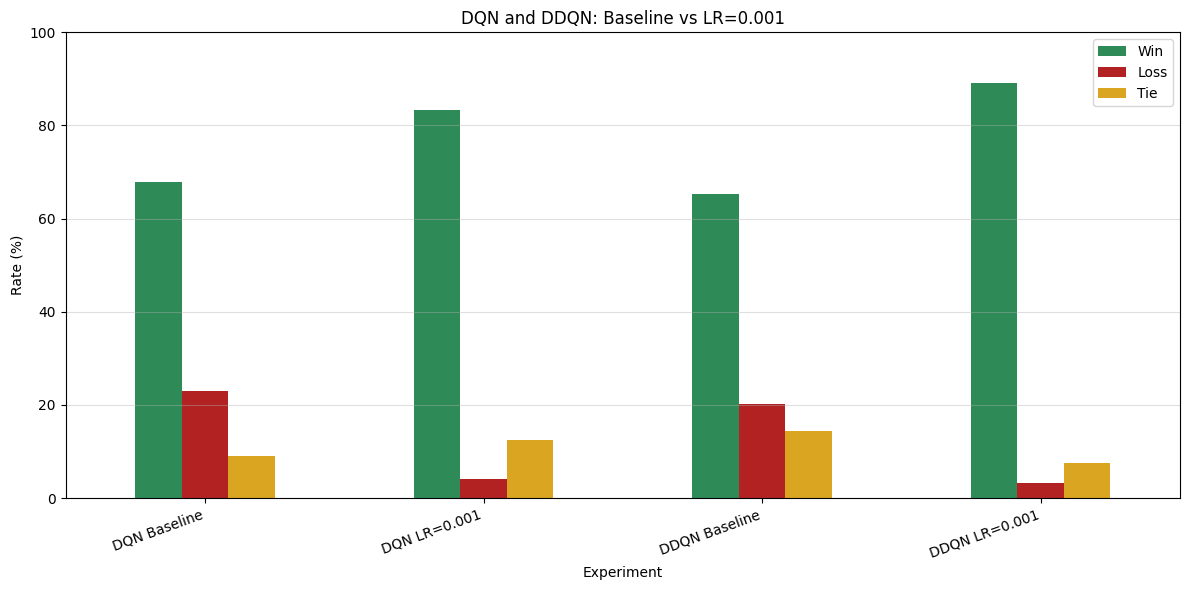

Comparison saved: /content/drive/MyDrive/Projects/Project 4/results/deep_comparison/deep_learning_rate_comparison.csv


In [21]:
dqn_improved_evaluation = (
    evaluate_deep_agent_batched(
        dqn_improved_agent,
        DEEP_EVALUATION_GAMES,
        DEEP_EVALUATION_SEED
    )
)

ddqn_improved_evaluation = (
    evaluate_deep_agent_batched(
        ddqn_improved_agent,
        DEEP_EVALUATION_GAMES,
        DEEP_EVALUATION_SEED
    )
)

deep_learning_rate_comparison_df = pd.DataFrame([
    {
        "experiment": "DQN Baseline",
        "learning_rate": 0.01,
        **dqn_evaluation
    },
    {
        "experiment": "DQN LR=0.001",
        "learning_rate": 0.001,
        **dqn_improved_evaluation
    },
    {
        "experiment": "DDQN Baseline",
        "learning_rate": 0.01,
        **ddqn_evaluation
    },
    {
        "experiment": "DDQN LR=0.001",
        "learning_rate": 0.001,
        **ddqn_improved_evaluation
    }
])

DEEP_LR_COMPARISON_FILE = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_learning_rate_comparison.csv"
)
deep_learning_rate_comparison_df.to_csv(
    DEEP_LR_COMPARISON_FILE,
    index=False
)

comparison_columns = [
    "experiment",
    "evaluation_games",
    "win_rate",
    "loss_rate",
    "tie_rate"
]

print("Baseline vs improved greedy evaluation:")
display(
    deep_learning_rate_comparison_df[
        comparison_columns
    ]
)

plot_df = (
    deep_learning_rate_comparison_df
    .set_index("experiment")
    [
        [
            "win_rate",
            "loss_rate",
            "tie_rate"
        ]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6),
    color=[
        "seagreen",
        "firebrick",
        "goldenrod"
    ]
)

ax.set_title(
    "DQN and DDQN: Baseline vs LR=0.001"
)
ax.set_xlabel("Experiment")
ax.set_ylabel("Rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4)
ax.legend(["Win", "Loss", "Tie"])

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

DEEP_LR_COMPARISON_PLOT = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_learning_rate_comparison.png"
)
plt.savefig(
    DEEP_LR_COMPARISON_PLOT,
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(
    f"Comparison saved: "
    f"{DEEP_LR_COMPARISON_FILE}"
)

### Training Stability Comparison

The curves show exploratory training performance in 50-episode windows, not repeated greedy evaluations of a fixed model. The summary uses the final five windows (episodes 751–1000). A lower standard deviation means less within-run variation in that metric; it does not establish convergence or reproducibility across training seeds. These summaries need not rank agents in the same order as final greedy evaluation.

Late-training stability comparison:


,experiment,late_win_rate_mean,late_win_rate_std,late_loss_rate_mean,late_loss_rate_std,late_tie_rate_mean,late_tie_rate_std
0,DQN Baseline,69.6,6.2290,15.2,5.7619,15.2,3.3466
1,DQN LR=0.001,83.6,3.2863,8.4,2.6077,8.0,4.8990
2,DDQN Baseline,78.8,6.2610,11.6,4.3359,9.6,2.1909
3,DDQN LR=0.001,84.0,4.0000,8.8,4.1473,7.2,2.6833


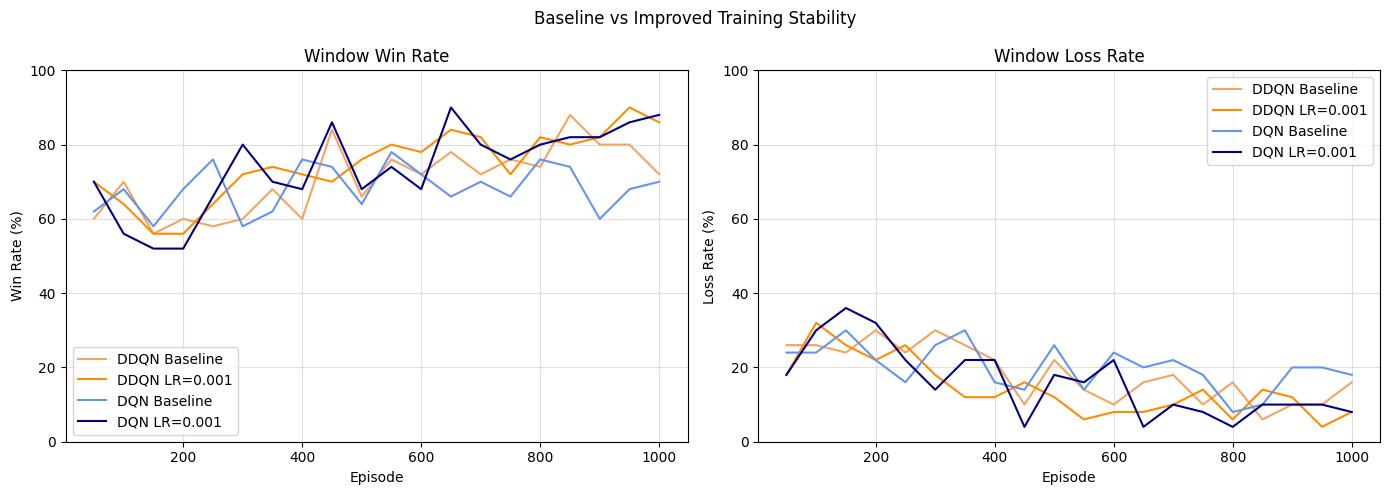

Stability comparison saved: /content/drive/MyDrive/Projects/Project 4/results/deep_comparison/deep_learning_rate_stability.csv


In [22]:
LATE_TRAINING_WINDOWS = 5

baseline_history_df = (
    training_1000_history_df.copy()
)
baseline_history_df["learning_rate"] = 0.01
baseline_history_df["experiment"] = (
    baseline_history_df["algorithm"]
    + " Baseline"
)

improved_history_df = (
    improved_training_history_df.copy()
)
improved_history_df["learning_rate"] = 0.001
improved_history_df["experiment"] = (
    improved_history_df["algorithm"]
    + " LR=0.001"
)

all_deep_history_df = pd.concat(
    [
        baseline_history_df,
        improved_history_df
    ],
    ignore_index=True
)

late_training_df = (
    all_deep_history_df
    .sort_values(["experiment", "episode"])
    .groupby("experiment", group_keys=False)
    .tail(LATE_TRAINING_WINDOWS)
    .copy()
)

deep_stability_comparison_df = (
    late_training_df
    .groupby(
        [
            "experiment",
            "algorithm",
            "learning_rate"
        ]
    )
    .agg(
        late_win_rate_mean=(
            "window_win_rate",
            "mean"
        ),
        late_win_rate_std=(
            "window_win_rate",
            "std"
        ),
        late_loss_rate_mean=(
            "window_loss_rate",
            "mean"
        ),
        late_loss_rate_std=(
            "window_loss_rate",
            "std"
        ),
        late_tie_rate_mean=(
            "window_tie_rate",
            "mean"
        ),
        late_tie_rate_std=(
            "window_tie_rate",
            "std"
        )
    )
    .reset_index()
)

experiment_order = [
    "DQN Baseline",
    "DQN LR=0.001",
    "DDQN Baseline",
    "DDQN LR=0.001"
]

deep_stability_comparison_df[
    "experiment"
] = pd.Categorical(
    deep_stability_comparison_df["experiment"],
    categories=experiment_order,
    ordered=True
)

deep_stability_comparison_df = (
    deep_stability_comparison_df
    .sort_values("experiment")
    .reset_index(drop=True)
)

numeric_columns = (
    deep_stability_comparison_df
    .select_dtypes(include=np.number)
    .columns
)
deep_stability_comparison_df[
    numeric_columns
] = deep_stability_comparison_df[
    numeric_columns
].round(4)

DEEP_STABILITY_COMPARISON_FILE = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_learning_rate_stability.csv"
)
deep_stability_comparison_df.to_csv(
    DEEP_STABILITY_COMPARISON_FILE,
    index=False
)

print("Late-training stability comparison:")
display(
    deep_stability_comparison_df[
        [
            "experiment",
            "late_win_rate_mean",
            "late_win_rate_std",
            "late_loss_rate_mean",
            "late_loss_rate_std",
            "late_tie_rate_mean",
            "late_tie_rate_std"
        ]
    ]
)


experiment_colors = {
    "DQN Baseline": "cornflowerblue",
    "DQN LR=0.001": "navy",
    "DDQN Baseline": "sandybrown",
    "DDQN LR=0.001": "darkorange"
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for experiment, history_df in (
    all_deep_history_df.groupby("experiment")
):
    history_df = history_df.sort_values("episode")
    color = experiment_colors[experiment]

    axes[0].plot(
        history_df["episode"],
        history_df["window_win_rate"],
        label=experiment,
        color=color
    )
    axes[1].plot(
        history_df["episode"],
        history_df["window_loss_rate"],
        label=experiment,
        color=color
    )

axes[0].set_title("Window Win Rate")
axes[0].set_ylabel("Win Rate (%)")
axes[1].set_title("Window Loss Rate")
axes[1].set_ylabel("Loss Rate (%)")

for axis in axes:
    axis.set_xlabel("Episode")
    axis.set_ylim(0, 100)
    axis.grid(alpha=0.4)
    axis.legend()

fig.suptitle(
    "Baseline vs Improved Training Stability"
)
plt.tight_layout()

DEEP_STABILITY_COMPARISON_PLOT = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_learning_rate_stability.png"
)
plt.savefig(
    DEEP_STABILITY_COMPARISON_PLOT,
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(
    f"Stability comparison saved: "
    f"{DEEP_STABILITY_COMPARISON_FILE}"
)

### Baseline vs Lower-LR Value-Estimation Gaps

All four models use the same state set, rewards, discount factor and rollout seeds. The plots retain the term “overestimation” for the empirical prediction-minus-policy-return diagnostic defined above. Smaller mean gaps alone are insufficient to establish reduced maximization bias; median, frequency and absolute-error results must also be considered.

DDQN diagnostic: 100%|██████████| 2423/2423 [00:01<00:00, 1278.74it/s]


Baseline vs improved overestimation:


,experiment,mean_overestimation_gap,median_overestimation_gap,positive_gap_rate,mean_absolute_gap
0,DQN Baseline,1.5747,0.1206,60.4622,1.7634
1,DQN LR=0.001,1.1127,0.2231,70.7388,1.3227
2,DDQN Baseline,1.5214,0.0445,53.5287,1.8377
3,DDQN LR=0.001,1.0215,0.2570,72.9674,1.2529


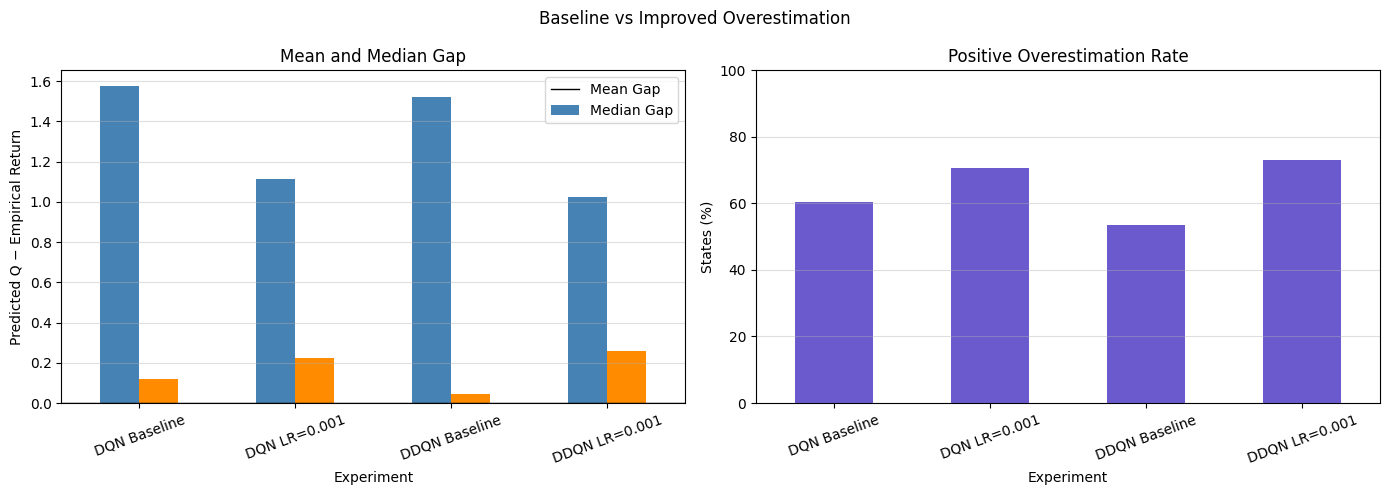

Overestimation comparison saved: /content/drive/MyDrive/Projects/Project 4/results/deep_comparison/deep_learning_rate_overestimation_summary.csv


In [23]:
dqn_improved_overestimation_df = (
    estimate_overestimation(
        dqn_improved_agent,
        legal_x_turn_states,
        improved_deep_config["rewards"],
        improved_deep_config["gamma"],
        OVER_ESTIMATION_ROLLOUTS,
        OVER_ESTIMATION_SEED
    )
)

ddqn_improved_overestimation_df = (
    estimate_overestimation(
        ddqn_improved_agent,
        legal_x_turn_states,
        improved_deep_config["rewards"],
        improved_deep_config["gamma"],
        OVER_ESTIMATION_ROLLOUTS,
        OVER_ESTIMATION_SEED
    )
)

all_overestimation_runs_df = pd.concat(
    [
        dqn_overestimation_df.assign(
            experiment="DQN Baseline",
            learning_rate=0.01
        ),
        dqn_improved_overestimation_df.assign(
            experiment="DQN LR=0.001",
            learning_rate=0.001
        ),
        ddqn_overestimation_df.assign(
            experiment="DDQN Baseline",
            learning_rate=0.01
        ),
        ddqn_improved_overestimation_df.assign(
            experiment="DDQN LR=0.001",
            learning_rate=0.001
        )
    ],
    ignore_index=True
)

learning_rate_overestimation_summary_df = (
    summarize_overestimation(
        all_overestimation_runs_df,
        [
            "experiment",
            "algorithm",
            "learning_rate"
        ]
    )
)

experiment_order = [
    "DQN Baseline",
    "DQN LR=0.001",
    "DDQN Baseline",
    "DDQN LR=0.001"
]

learning_rate_overestimation_summary_df[
    "experiment"
] = pd.Categorical(
    learning_rate_overestimation_summary_df[
        "experiment"
    ],
    categories=experiment_order,
    ordered=True
)

learning_rate_overestimation_summary_df = (
    learning_rate_overestimation_summary_df
    .sort_values("experiment")
    .reset_index(drop=True)
)

DEEP_LR_OVERESTIMATION_SUMMARY_FILE = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_learning_rate_overestimation_summary.csv"
)

learning_rate_overestimation_summary_df.to_csv(
    DEEP_LR_OVERESTIMATION_SUMMARY_FILE,
    index=False
)

print("Baseline vs improved overestimation:")
display(
    learning_rate_overestimation_summary_df[
        [
            "experiment",
            "mean_overestimation_gap",
            "median_overestimation_gap",
            "positive_gap_rate",
            "mean_absolute_gap"
        ]
    ]
)


overestimation_plot_df = (
    learning_rate_overestimation_summary_df
    .set_index("experiment")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

overestimation_plot_df[
    [
        "mean_overestimation_gap",
        "median_overestimation_gap"
    ]
].plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "darkorange"]
)

overestimation_plot_df[
    "positive_gap_rate"
].plot(
    kind="bar",
    ax=axes[1],
    color="slateblue"
)

axes[0].axhline(
    0,
    color="black",
    linewidth=1
)
axes[0].set_title("Mean and Median Gap")
axes[0].set_ylabel(
    "Predicted Q − Empirical Return"
)
axes[0].legend(["Mean Gap", "Median Gap"])

axes[1].set_title("Positive Overestimation Rate")
axes[1].set_ylabel("States (%)")
axes[1].set_ylim(0, 100)

for axis in axes:
    axis.set_xlabel("Experiment")
    axis.tick_params(
        axis="x",
        rotation=20
    )
    axis.grid(axis="y", alpha=0.4)

fig.suptitle(
    "Baseline vs Improved Overestimation"
)
plt.tight_layout()

DEEP_LR_OVERESTIMATION_PLOT = (
    DEEP_COMPARISON_RESULTS_PATH
    / "deep_learning_rate_overestimation.png"
)
plt.savefig(
    DEEP_LR_OVERESTIMATION_PLOT,
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print(
    f"Overestimation comparison saved: "
    f"{DEEP_LR_OVERESTIMATION_SUMMARY_FILE}"
)

### Greedy Game Play Demonstration

Each lower-LR agent plays one greedy game as X against random O (seed 7). In this run, DQN wins in 5 moves and DDQN in 7. These examples illustrate gameplay; they do not rank the policies. Quantitative conclusions use the 5000-game evaluation.

,algorithm,seed,result,moves
0,DQN,7,win,5
1,DDQN,7,win,7


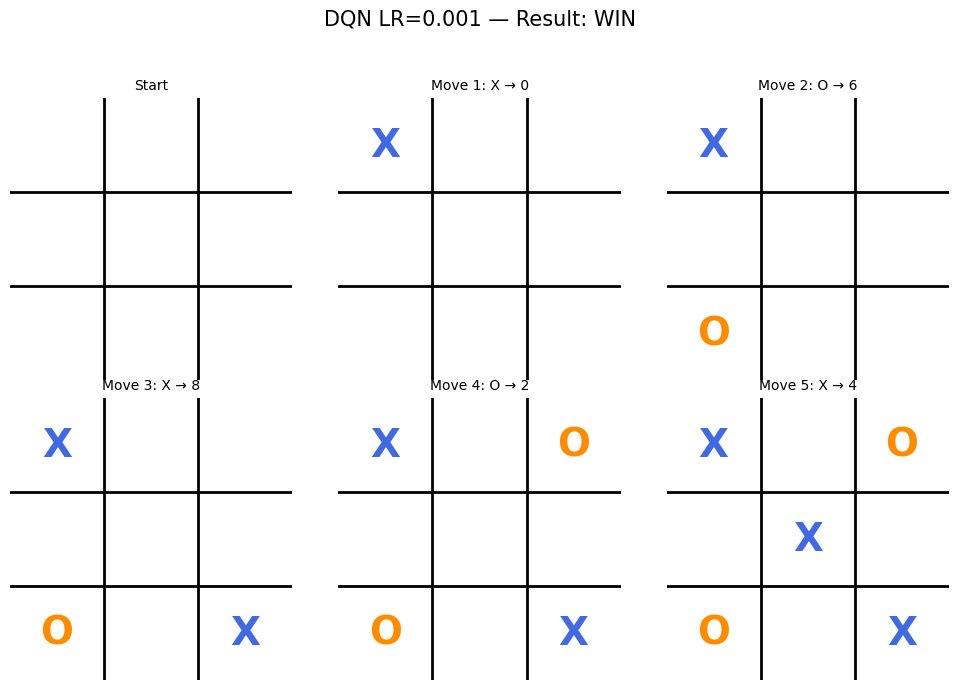

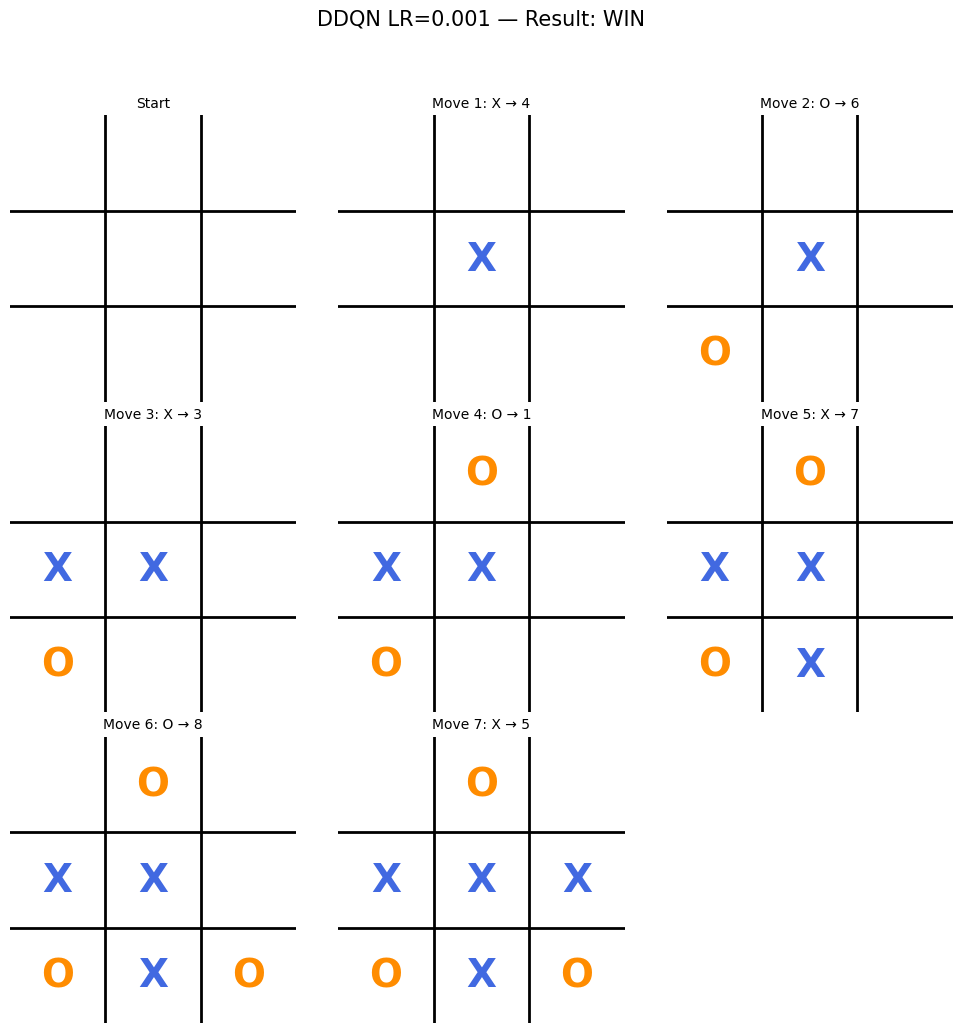

DQN demonstration saved: /content/drive/MyDrive/Projects/Project 4/results/dqn/dqn_lr_0.001_demo.png
DDQN demonstration saved: /content/drive/MyDrive/Projects/Project 4/results/ddqn/ddqn_lr_0.001_demo.png


In [24]:
def play_deep_demo(agent, seed=7):
    """Play one greedy game and store its board sequence."""
    opponent_rng = random.Random(seed)
    local_game = TicTacToe(BOARD_SIZE)

    board_states = [
        local_game.board.copy()
    ]
    state_labels = ["Start"]
    move_number = 1

    while True:
        state = encode_board(local_game.board)
        legal_actions = (
            local_game.available_moves()
        )
        x_action = agent.act(
            state,
            legal_actions,
            training=False
        )

        local_game.make_move(x_action, "X")
        board_states.append(
            local_game.board.copy()
        )
        state_labels.append(
            f"Move {move_number}: X → {x_action}"
        )
        move_number += 1

        if local_game.current_winner == "X":
            result = "win"
            break

        if not local_game.empty_squares():
            result = "tie"
            break

        o_action = opponent_rng.choice(
            local_game.available_moves()
        )
        local_game.make_move(o_action, "O")
        board_states.append(
            local_game.board.copy()
        )
        state_labels.append(
            f"Move {move_number}: O → {o_action}"
        )
        move_number += 1

        if local_game.current_winner == "O":
            result = "loss"
            break

        if not local_game.empty_squares():
            result = "tie"
            break

    return {
        "algorithm": agent.algorithm,
        "seed": seed,
        "result": result,
        "board_states": board_states,
        "state_labels": state_labels
    }


def plot_deep_demo_sequence(
    demo,
    output_file
):
    """Plot every board state in one game."""
    board_states = demo["board_states"]
    state_labels = demo["state_labels"]
    columns = 3
    rows = int(np.ceil(
        len(board_states) / columns
    ))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(10, 3.5 * rows)
    )
    axes = np.atleast_1d(
        axes
    ).flatten()

    for index, board in enumerate(
        board_states
    ):
        axis = axes[index]

        for line in [0.5, 1.5]:
            axis.axvline(
                line,
                color="black",
                linewidth=2
            )
            axis.axhline(
                line,
                color="black",
                linewidth=2
            )

        for position, symbol in enumerate(board):
            if symbol == " ":
                continue

            row = position // BOARD_SIZE
            column = position % BOARD_SIZE

            axis.text(
                column,
                row,
                symbol,
                ha="center",
                va="center",
                fontsize=28,
                fontweight="bold",
                color=(
                    "royalblue"
                    if symbol == "X"
                    else "darkorange"
                )
            )

        axis.set_xlim(-0.5, 2.5)
        axis.set_ylim(2.5, -0.5)
        axis.set_aspect("equal")
        axis.axis("off")
        axis.set_title(
            state_labels[index],
            fontsize=10
        )

    for axis in axes[len(board_states):]:
        axis.axis("off")

    fig.suptitle(
        f"{demo['algorithm']} LR=0.001 — "
        f"Result: {demo['result'].upper()}",
        fontsize=15
    )
    plt.tight_layout(
        rect=[0, 0, 1, 0.94]
    )
    plt.savefig(
        output_file,
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()


DEEP_DEMO_SEED = 7

dqn_improved_demo = play_deep_demo(
    dqn_improved_agent,
    DEEP_DEMO_SEED
)
ddqn_improved_demo = play_deep_demo(
    ddqn_improved_agent,
    DEEP_DEMO_SEED
)

deep_demo_summary_df = pd.DataFrame([
    {
        "algorithm": demo["algorithm"],
        "seed": demo["seed"],
        "result": demo["result"],
        "moves": len(demo["board_states"]) - 1
    }
    for demo in [
        dqn_improved_demo,
        ddqn_improved_demo
    ]
])

display(deep_demo_summary_df)

DQN_DEMO_PLOT_FILE = (
    DQN_RESULTS_PATH
    / "dqn_lr_0.001_demo.png"
)
DDQN_DEMO_PLOT_FILE = (
    DDQN_RESULTS_PATH
    / "ddqn_lr_0.001_demo.png"
)

plot_deep_demo_sequence(
    dqn_improved_demo,
    DQN_DEMO_PLOT_FILE
)
plot_deep_demo_sequence(
    ddqn_improved_demo,
    DDQN_DEMO_PLOT_FILE
)

print(f"DQN demonstration saved: {DQN_DEMO_PLOT_FILE}")
print(f"DDQN demonstration saved: {DDQN_DEMO_PLOT_FILE}")

### Comparison with the Q-Learning Baseline

The saved Q-learning baseline and the two lower-LR neural agents are evaluated through the same function over 5000 games each, with matching opponent seeds. All agents play as X against random O, without learning updates.

Known-state actions are greedy; unseen Q-table states use a separate random fallback generator. Training budgets and rewards differ, so this compares the resulting trained models rather than isolating the effect of the algorithm.

Artifact loaded: /content/drive/MyDrive/Projects/Project 4/saved_models/q_learning/baseline/q_corrected_1m.pkl
Evaluating Q-learning baseline: 5,000 games...
Evaluating DQN LR=0.001: 5,000 games...
Evaluating DDQN LR=0.001: 5,000 games...


,model,evaluation_games,wins,losses,ties,win_rate,loss_rate,tie_rate
0,Q-learning baseline,5000,4232,581,187,84.64,11.62,3.74
1,DQN LR=0.001,5000,4164,208,628,83.28,4.16,12.56
2,DDQN LR=0.001,5000,4457,163,380,89.14,3.26,7.60


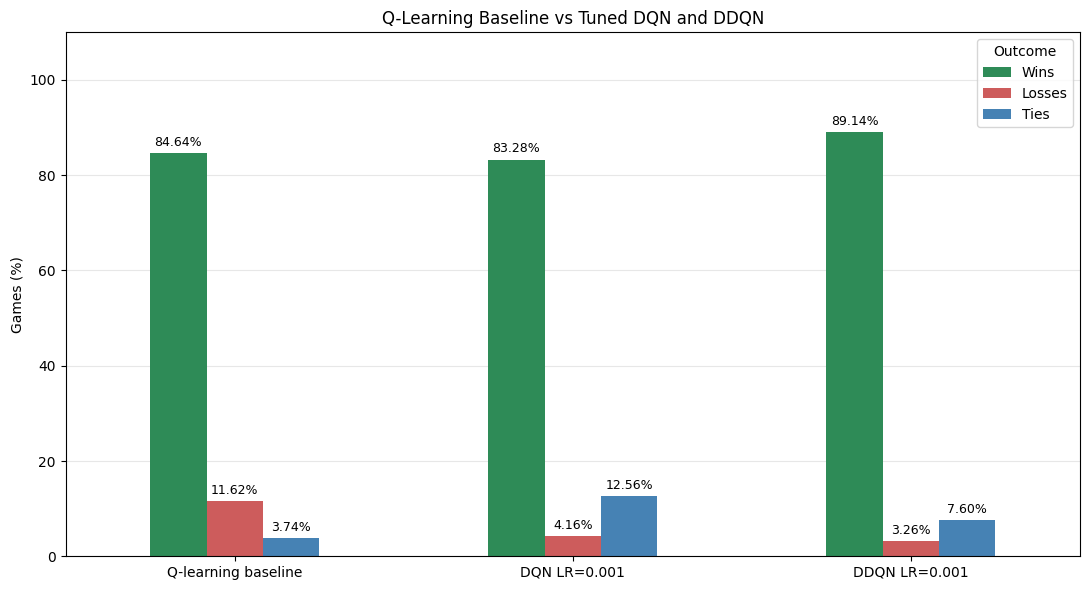

DQN LR=0.001 vs Q-learning baseline: win-rate change -1.36 pp; loss-rate change -7.46 pp.
DDQN LR=0.001 vs Q-learning baseline: win-rate change +4.50 pp; loss-rate change -8.36 pp.

Same evaluation protocol; training budgets and rewards differ.
This compares trained models, not the isolated effect of each algorithm.

Saved table: /content/drive/MyDrive/Projects/Project 4/results/deep_comparison/q_baseline_vs_deep_5000.csv
Saved plot: /content/drive/MyDrive/Projects/Project 4/results/deep_comparison/q_baseline_vs_deep_5000.png


In [25]:
from types import SimpleNamespace


class QTableEvaluationAdapter:
    """Expose a saved Q-table through the existing evaluation interface."""

    def __init__(self, table, fallback_seed=1002026):
        self.table = table
        self.rng = random.Random(fallback_seed)

    def predict(self, states, verbose=0):
        predictions = np.full((len(states), ACTION_SIZE), -np.inf)
        symbols = {0: " ", 1: "X", -1: "O"}

        for index, state in enumerate(states):
            state_key = "".join(symbols[int(value)] for value in state)
            legal_actions = np.flatnonzero(state == 0).tolist()

            if not legal_actions:
                raise ValueError("Evaluation received a terminal board.")

            if state_key in self.table:
                for action in legal_actions:
                    predictions[index, action] = self.table[state_key].get(action, 0)
            else:
                # Separate RNG: fallback actions do not consume opponent randomness.
                action = self.rng.choice(legal_actions)
                predictions[index, action] = 0

        return predictions


# Load the baseline explicitly, not a tuned Q-learning experiment.
comparison_q_table = load_pickle(Q_MODEL_FILE)
comparison_q_agent = SimpleNamespace(
    algorithm="Q-learning baseline",
    model=QTableEvaluationAdapter(comparison_q_table)
)

COMPARISON_GAMES = 5000
COMPARISON_SEED = 2026

comparison_agents = [
    ("Q-learning baseline", comparison_q_agent),
    ("DQN LR=0.001", dqn_improved_agent),
    ("DDQN LR=0.001", ddqn_improved_agent)
]

comparison_rows = []

for label, agent in comparison_agents:
    print(f"Evaluating {label}: {COMPARISON_GAMES:,} games...")
    result = evaluate_deep_agent_batched(
        agent,
        num_games=COMPARISON_GAMES,
        seed=COMPARISON_SEED
    )
    result["model"] = label
    comparison_rows.append(result)

cross_method_comparison_df = pd.DataFrame(comparison_rows)

comparison_columns = [
    "model", "evaluation_games", "wins", "losses", "ties",
    "win_rate", "loss_rate", "tie_rate"
]

assert (
    cross_method_comparison_df[["wins", "losses", "ties"]].sum(axis=1)
    == COMPARISON_GAMES
).all()

display(cross_method_comparison_df[comparison_columns].round(2))

comparison_path = RESULTS_PATH / "deep_comparison"
comparison_path.mkdir(parents=True, exist_ok=True)

comparison_csv = comparison_path / "q_baseline_vs_deep_5000.csv"
comparison_png = comparison_path / "q_baseline_vs_deep_5000.png"

cross_method_comparison_df.to_csv(comparison_csv, index=False)

plot_df = cross_method_comparison_df.set_index("model")[
    ["win_rate", "loss_rate", "tie_rate"]
].rename(columns={
    "win_rate": "Wins",
    "loss_rate": "Losses",
    "tie_rate": "Ties"
})

ax = plot_df.plot(
    kind="bar", figsize=(11, 6), rot=0,
    color=["seagreen", "indianred", "steelblue"]
)
ax.set_title("Q-Learning Baseline vs Tuned DQN and DDQN")
ax.set_xlabel("")
ax.set_ylabel("Games (%)")
ax.set_ylim(0, 110)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(title="Outcome")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(comparison_png, dpi=150, bbox_inches="tight")
plt.show()

baseline = cross_method_comparison_df.iloc[0]

for _, row in cross_method_comparison_df.iloc[1:].iterrows():
    win_change = row["win_rate"] - baseline["win_rate"]
    loss_change = row["loss_rate"] - baseline["loss_rate"]
    print(
        f"{row['model']} vs Q-learning baseline: "
        f"win-rate change {win_change:+.2f} pp; "
        f"loss-rate change {loss_change:+.2f} pp."
    )

print("\nSame evaluation protocol; training budgets and rewards differ.")
print("This compares trained models, not the isolated effect of each algorithm.")
print(f"\nSaved table: {comparison_csv}")
print(f"Saved plot: {comparison_png}")

### Cross-Method Results

Under the shared evaluation protocol, the Q-learning baseline achieved 84.64% wins, 11.62% losses and 3.74% ties.

Tuned DQN achieved 83.28% wins: 1.36 percentage points below the baseline. However, its loss rate was 7.46 points lower, with more games ending in draws.

Tuned DDQN achieved 89.14% wins and 3.26% losses, improving on the baseline by 4.50 points in win rate and 8.36 points in loss rate.

Thus, DDQN met the goal of exceeding the Q-learning baseline on both metrics in this evaluation. DQN reduced losses but did not exceed its win rate. These results do not establish superiority over tuned Q-learning, Monte Carlo or across independent training runs.

## 3.b–c - Results and Discussion

### 3.b - Architecture and Learning-Rate Result

The implemented 9–64–64–32–9 network successfully learns a policy. The latest greedy evaluation gives:

| Algorithm | Adam LR | Win rate | Loss rate | Tie rate |
|---|---:|---:|---:|---:|
| DQN | 0.01 | 67.92% | 23.00% | 9.08% |
| DDQN | 0.01 | 65.36% | 20.26% | 14.38% |
| DQN | 0.001 | 83.28% | 4.16% | 12.56% |
| DDQN | 0.001 | 89.14% | 3.26% | 7.60% |

Reducing LR raises DQN's win rate by **15.36 percentage points** and DDQN's by **23.78 points**, while sharply reducing losses. This supports the lower-LR configuration for these runs, although it does not prove that the LR is optimal or that neural methods outperform the earlier tabular agents.

### 3.c - Does DDQN Improve on DQN?

At baseline LR, DDQN has fewer losses but also fewer wins and more ties: there is no uniform gameplay advantage. At LR `0.001`, DDQN wins **5.86 percentage points** more often than DQN and loses **0.90 points** less often. Thus the tuned DDQN has the strongest final gameplay results among these four runs.

**Training stability.** Late-window win-rate standard deviations decrease from **6.2290 to 3.2863** for DQN and from **6.2610 to 4.0000** for DDQN after lowering LR. Late-window loss-rate variation also decreases for both. However, DDQN is not less variable than DQN on either of these metrics at the lower LR; its tie-rate variation is lower. The evidence supports reduced win/loss variation with lower LR, not a general DDQN stability advantage.

**Value-estimation gaps.** DDQN has a smaller mean gap at both LRs: **1.5214 vs 1.5747** at baseline, and **1.0215 vs 1.1127** at lower LR. The remaining evidence is mixed:

- At baseline, DDQN has a lower median and positive-gap frequency, but a larger mean absolute gap (**1.8377 vs 1.7634**).
- At lower LR, DDQN has a smaller mean absolute gap (**1.2529 vs 1.3227**), but a larger median (**0.2570 vs 0.2231**) and positive-gap frequency (**72.97% vs 70.74%**).

Lowering LR reduces mean and absolute gaps for both algorithms, but increases their medians and positive-gap frequencies. Gap magnitude and frequency therefore must not be conflated. This diagnostic provides mixed, limited evidence consistent with some DDQN benefit; it does not isolate or prove reduced maximization bias.

### Conclusion and Limitations

The clearest finding is the improvement from lowering LR. Tuned DDQN achieved the strongest final win/loss rates among the evaluated neural models and exceeded the Q-learning baseline under the shared evaluation protocol. However, it showed no general training-stability or value-estimation advantage over DQN.

These findings concern X playing first against random O, with one training seed per configuration. Evaluation games do not replace independent training runs or demonstrate optimal play. Different training budgets and rewards limit cross-method conclusions; superiority over tuned Q-learning or Monte Carlo was not established.